In [2]:
#import zsx_some_tools as st

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
import seaborn as sns; sns.set(color_codes=True)
#import networkx as nx
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import pymc3 as pm
import miseq_functions as jnf
import drug_info as di
from scipy import stats
import microbiome_data_processing_functions as mdpf
%matplotlib inline
%load_ext autoreload
sns.set_style('whitegrid')

WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.


In [2]:
def calculate_dxdt(current_dataset, all_meds, all_weights, antibacterials, antifungals):
    all_dlog_dt_df = pd.DataFrame(columns = current_dataset.columns)
    all_geo_mean_df = pd.DataFrame(columns = current_dataset.columns)
   # all_weights = 0
    for baby in np.unique(current_dataset.babyid):
        #print(baby)

        # get data for current replicate
        current_data = current_dataset[current_dataset['babyid'] == baby].set_index('day')

        # get abs abundances
        current_abs_abundances = current_data.copy().drop(['babyid'],axis=1)

        # add pseudocount
        current_abs_abundances[current_abs_abundances == 0] = 0.001

        # take logs
        logged_abs_abundances = current_abs_abundances.copy().astype('float').sort_index()
        logged_abs_abundances = logged_abs_abundances.apply(np.log)

        shift_df = logged_abs_abundances.copy()
        tmp = pd.DataFrame(index = [-1], columns = logged_abs_abundances.columns).fillna(0)
        shift_df = pd.concat([shift_df, tmp]).sort_index()

        shift_df = shift_df.reset_index().rename(columns = {"index":'day'})
        logged_abs_abundances = logged_abs_abundances.reset_index()

        # get delta_time, delta_logged_abundance
        delta_logged_abs = logged_abs_abundances - shift_df
        delta_logged_abs = delta_logged_abs.iloc[1:-1,:]

        # delta log / delta time
        #  delta_abs_delta_t = delta_logged_abs.astype(float).div(delta_logged_abs['day'].astype(float),0)  
        # 如果非连续则需要除以天数差值求平均，且需注意第一行术前的天数出现问题
        delta_abs_delta_t = delta_logged_abs.copy()
        delta_abs_delta_t.loc[:,'babyid'] = baby

        # concat matrix
        all_dlog_dt_df = pd.concat([all_dlog_dt_df, delta_abs_delta_t], ignore_index=True)

        # get geometric mean of absolute abundances
        geometric_means = pd.DataFrame(columns=current_abs_abundances.columns)

        tmp = current_abs_abundances.copy().reset_index().astype(float)
        tmp[tmp==0.001]=0

        for jx in tmp.index[0:-1]:
            geometric_means.loc[jx+1,geometric_means.columns[0]:] = stats.mstats.gmean(tmp.loc[jx:jx+1, geometric_means.columns[0]:], axis=0)

        individual_weight, individual_drugs = mdpf.get_baby_weights_and_drugs(baby, all_meds, all_weights)
        try:
            merged_list = pd.concat([pd.DataFrame(antibacterials), pd.DataFrame(antifungals)], sort=True)[0]
            matching_drugs = individual_drugs.index[individual_drugs.index.isin(merged_list)]
            individual_drugs = individual_drugs.loc[matching_drugs,:]
        except:
            individual_drugs = pd.DataFrame(0, index = antibacterials, columns = individual_drugs.columns)
    #     print(matching_drugs)
    #     print(pd.concat([pd.DataFrame(antibacterials),pd.DataFrame(antifungals)])) 


        individual_drugs = individual_drugs*1e5
        individual_drugs = individual_drugs.dropna()
        #print(current_abs_abundances.index[:-1])
       # break   

        for ixix, ix in enumerate(current_abs_abundances.index[:-1]):
            timestep_drugs = individual_drugs.loc[:,current_abs_abundances.index[ixix]:current_abs_abundances.index[ixix+1]]
            drug_ix=3
            for drug in timestep_drugs.index:
                mean_drug_over_timestep = np.mean(timestep_drugs.loc[drug,:])
                geometric_means.loc[ixix+1, drug] = mean_drug_over_timestep

        geometric_means.loc[:,'babyid'] = baby
        all_geo_mean_df = pd.concat([all_geo_mean_df, geometric_means], ignore_index=True)

    all_geo_mean_df = all_geo_mean_df.fillna(0)
    all_geo_mean_df = all_geo_mean_df.drop(all_geo_mean_df.columns[all_geo_mean_df.sum()==0],axis=1)
    all_geo_mean_df = all_geo_mean_df.drop('babyid',axis=1)

    return(all_geo_mean_df, all_dlog_dt_df)

# data

In [12]:
tl='genus' 
prevalence_threshold = 30
relative_abundance_threshold = 0.01 # Note we filter out any genera with low prevalence and abundance

#antibacterials, antifungals, vaccines = di.load_drug_types()

antibacterials = [ "Linezolid" ,"Amikacin Sulfate" , "Meropenem",  "Piperacillin Sodium and Tazobactam Sodium",
                  "Cefuroxime Sodium" , "Cefoperazone Sodium and Sulbactam Sodium"  ,"Imipenem and Cilastatin"    ]
antifungals = []

all_meds = pd.read_table('E:/projects/肝移植/fig3/glv/medicine0.txt')


data_bacteria  = pd.read_table('E:/projects/肝移植/fig3/glv/bacteria_w.txt',index_col=0)
data_fungi  = pd.read_table('E:/projects/肝移植/fig3/glv/fungi_w.txt',index_col=0)
data = pd.concat([data_bacteria, data_fungi.drop(['babyid', 'day'],axis=1)],axis=1, sort=False).fillna(0)
otu_table = pd.read_table('E:/projects/肝移植/fig3/glv/tax.txt',index_col=0)

data_bacteria['babyid'] = data_bacteria['babyid'].astype(object)
data_fungi['babyid'] = data_fungi['babyid'].astype(object)

relative_bacteria = jnf.get_relative_abundances(data_bacteria)
relative_fungi = jnf.get_relative_abundances(data_fungi)

my_bacteria = jnf.filter_for_prevalence(relative_bacteria, prevalence_threshold, relative_abundance_threshold)
my_fungi = jnf.filter_for_prevalence(relative_fungi, prevalence_threshold, relative_abundance_threshold)

current_dataset = pd.concat([data.loc[:, ['day','babyid']],
                             data[my_bacteria],
                             data[my_fungi]], axis=1, sort=False)
current_dataset.day = current_dataset.day.astype(float)

current_dataset['babyid'] = current_dataset['babyid'].astype(object)

In [35]:
my_fungi

Index(['Neurospora', 'Pyricularia', 'Trichosporon', 'Ramularia', 'Aspergillus',
       'Candida', 'Penicillium', 'Fusarium', 'Colletotrichum', 'Saccharomyces',
       'Botrytis', 'Rhizophagus'],
      dtype='object')

In [15]:
### Calculate geometric means and dxdt ###
all_geo_mean_df, all_dlog_dt_df =  calculate_dxdt(current_dataset,
                                                      all_meds,
                                                      0,
                                                     antibacterials,
                                                     antifungals)

D:\environment\envs\pymc3\lib\site-packages\scipy\stats\stats.py:275: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.array(a, dtype=dtype))
D:\environment\envs\pymc3\lib\site-packages\scipy\stats\stats.py:275: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.array(a, dtype=dtype))
D:\environment\envs\pymc3\lib\site-packages\scipy\stats\stats.py:275: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.array(a, dtype=dtype))
D:\environment\envs\pymc3\lib\site-packages\scipy\stats\stats.py:275: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.array(a, dtype=dtype))
D:\environment\envs\pymc3\lib\site-packages\scipy\stats\stats.py:275: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.array(a, dtype=dtype))
D:\environment\envs\pymc3\lib\site-packages\scipy\stats\stats.py:275: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.array(a, dtype=dtype))


In [17]:
all_geo_mean_df

,Klebsiella,Streptococcus,Veillonella,Enterococcus,Bifidobacterium,Pseudomonas,Phocaeicola,Bacteroides,Rothia,Escherichia,...,Saccharomyces,Botrytis,Rhizophagus,Amikacin Sulfate,Imipenem and Cilastatin,Piperacillin Sodium and Tazobactam Sodium,Cefoperazone Sodium and Sulbactam Sodium,Cefuroxime Sodium,Meropenem,Linezolid
0,2.409349e+05,5.925578e+03,1.809334e+04,43518.985088,6.154012e+04,1.569990e+03,6053.942373,7798.372633,1.563738e+03,1445.224518,...,0.000000,872.871506,754.479434,100000.0,50000.0,0.0,0.0,0.0,0.0,0.0
1,6.515065e+05,2.462533e+04,1.901677e+04,44579.963547,9.895337e+04,6.683876e+04,9176.253451,14683.128106,1.170035e+04,4902.215063,...,120.622095,918.630502,355.101831,100000.0,50000.0,0.0,0.0,0.0,0.0,0.0
2,4.386764e+07,1.294683e+06,7.302445e+05,601670.646413,1.453908e+06,1.647176e+06,115056.137877,166414.443598,1.119697e+06,260807.125490,...,0.000000,0.000000,122.032948,100000.0,100000.0,0.0,0.0,0.0,0.0,0.0
3,4.350570e+07,5.338089e+05,1.188548e+06,840347.647521,1.916483e+06,4.595991e+04,185657.541688,248417.881370,3.661240e+05,195397.831237,...,0.000000,0.000000,156.556088,100000.0,100000.0,0.0,0.0,0.0,0.0,0.0
4,3.392540e+06,7.086667e+04,4.673113e+04,202450.134612,1.591343e+06,3.054921e+03,20246.111274,28842.341549,2.450345e+04,13433.541461,...,0.000000,0.000000,215.465192,100000.0,100000.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,1.602473e+07,6.916960e+04,6.693440e+04,6226.707155,3.173435e+04,7.664786e+06,56957.692237,121744.860904,1.676623e+03,577843.999694,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
145,9.640323e+05,4.814035e+04,5.933170e+04,3612.195954,5.737032e+04,1.037900e+06,117984.300258,58427.485090,3.792876e+03,460022.213421,...,0.000000,0.000000,686.701669,0.0,0.0,0.0,0.0,0.0,0.0,0.0
146,2.257632e+05,6.521668e+04,3.181581e+04,8931.767916,2.560763e+04,1.148583e+05,49254.179153,16261.962017,2.596081e+03,117940.972545,...,0.000000,164.454600,930.295427,0.0,0.0,0.0,0.0,0.0,0.0,0.0
147,4.392102e+05,6.306113e+05,1.535929e+05,270675.923352,5.133548e+04,1.673051e+05,137228.089442,41474.857273,4.398928e+03,177490.018901,...,133.008603,133.008603,1128.615330,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
all_Y = all_dlog_dt_df.dropna().drop(['babyid','day'],axis=1)
all_X = all_geo_mean_df
all_X = all_X.loc[all_Y.index,:]
all_X = jnf.clean_column_names(all_X)
all_Y = jnf.clean_column_names(all_Y)

In [21]:
all_X

,Klebsiella,Streptococcus,Veillonella,Enterococcus,Bifidobacterium,Pseudomonas,Phocaeicola,Bacteroides,Rothia,Escherichia,...,Saccharomyces,Botrytis,Rhizophagus,Amikacin_Sulfate,Imipenem_and_Cilastatin,Piperacillin_Sodium_and_Tazobactam_Sodium,Cefoperazone_Sodium_and_Sulbactam_Sodium,Cefuroxime_Sodium,Meropenem,Linezolid
0,2.409349e+05,5.925578e+03,1.809334e+04,43518.985088,6.154012e+04,1.569990e+03,6053.942373,7798.372633,1.563738e+03,1445.224518,...,0.000000,872.871506,754.479434,100000.0,50000.0,0.0,0.0,0.0,0.0,0.0
1,6.515065e+05,2.462533e+04,1.901677e+04,44579.963547,9.895337e+04,6.683876e+04,9176.253451,14683.128106,1.170035e+04,4902.215063,...,120.622095,918.630502,355.101831,100000.0,50000.0,0.0,0.0,0.0,0.0,0.0
2,4.386764e+07,1.294683e+06,7.302445e+05,601670.646413,1.453908e+06,1.647176e+06,115056.137877,166414.443598,1.119697e+06,260807.125490,...,0.000000,0.000000,122.032948,100000.0,100000.0,0.0,0.0,0.0,0.0,0.0
3,4.350570e+07,5.338089e+05,1.188548e+06,840347.647521,1.916483e+06,4.595991e+04,185657.541688,248417.881370,3.661240e+05,195397.831237,...,0.000000,0.000000,156.556088,100000.0,100000.0,0.0,0.0,0.0,0.0,0.0
4,3.392540e+06,7.086667e+04,4.673113e+04,202450.134612,1.591343e+06,3.054921e+03,20246.111274,28842.341549,2.450345e+04,13433.541461,...,0.000000,0.000000,215.465192,100000.0,100000.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,1.602473e+07,6.916960e+04,6.693440e+04,6226.707155,3.173435e+04,7.664786e+06,56957.692237,121744.860904,1.676623e+03,577843.999694,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
145,9.640323e+05,4.814035e+04,5.933170e+04,3612.195954,5.737032e+04,1.037900e+06,117984.300258,58427.485090,3.792876e+03,460022.213421,...,0.000000,0.000000,686.701669,0.0,0.0,0.0,0.0,0.0,0.0,0.0
146,2.257632e+05,6.521668e+04,3.181581e+04,8931.767916,2.560763e+04,1.148583e+05,49254.179153,16261.962017,2.596081e+03,117940.972545,...,0.000000,164.454600,930.295427,0.0,0.0,0.0,0.0,0.0,0.0,0.0
147,4.392102e+05,6.306113e+05,1.535929e+05,270675.923352,5.133548e+04,1.673051e+05,137228.089442,41474.857273,4.398928e+03,177490.018901,...,133.008603,133.008603,1128.615330,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
### Remove brackets, drop any antibiotics that occur fewer than 5 times ###
all_X = all_X.rename(columns={'Zosyn_(Piperacillin/tazobactam)':'Zosyn'})
copy_all_X = all_X.copy()
for col in all_X.columns:
    if len(all_X.loc[all_X[col]>0,:]) < 5:
        copy_all_X = copy_all_X.drop(col,1) 
all_X = copy_all_X


### Rename for fitting ###
my_bacteria = ['Escherichia_Shigella' if x=='Escherichia-Shigella' else x for x in my_bacteria]
my_bacteria = ['Clostridium_sensu_stricto_1' if x=='Clostridium sensu stricto 1' else x for x in my_bacteria]
my_bacteria = ['Clostridiaceae_1' if x=='Clostridiaceae 1' else x for x in my_bacteria]

my_list = ['Escherichia_Shigella',
           'Klebsiella',
           'Staphylococcus',
           'Enterococcus',
           'Candida']



In [9]:
all_Y.columns[8:]

Index(['Phocaeicola', 'Ramularia', 'Trichosporon', 'Aspergillus',
       'Penicillium', 'Neurospora', 'Saccharomyces', 'Candida', 'Pyricularia'],
      dtype='object')

In [70]:
model = pm.Model()

In [71]:
model

(149, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 974 seconds.
There were 268 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.5819746056122551, but should be close to 0.8. Try to increase the number of tuning steps.
There were 2472 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.06396299093774047, but should be close to 0.8. Try to increase the number of tuning steps.
The rhat statistic is larger than 1.4 for some parameters. The sampler did not converge.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future relea

Klebsiella


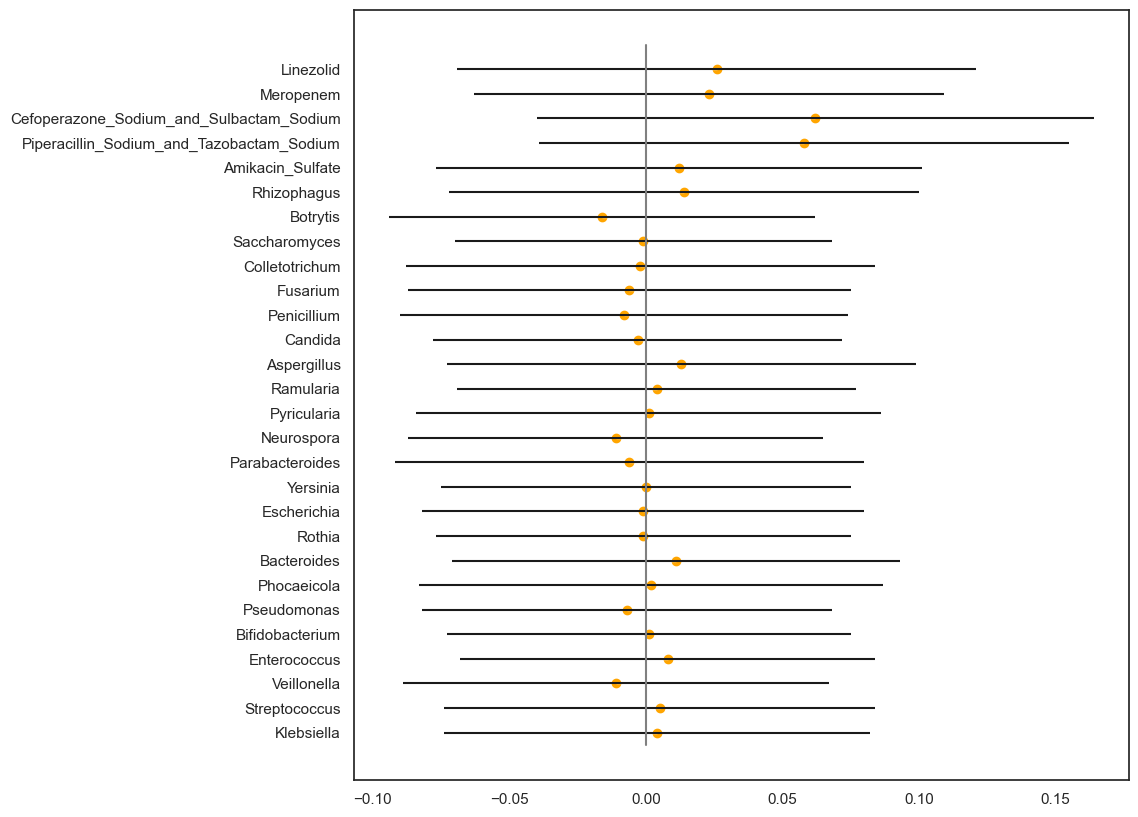

(149, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1397 seconds.
There were 88 divergences after tuning. Increase `target_accept` or reparameterize.
There were 315 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Streptococcus


<Figure size 640x480 with 0 Axes>

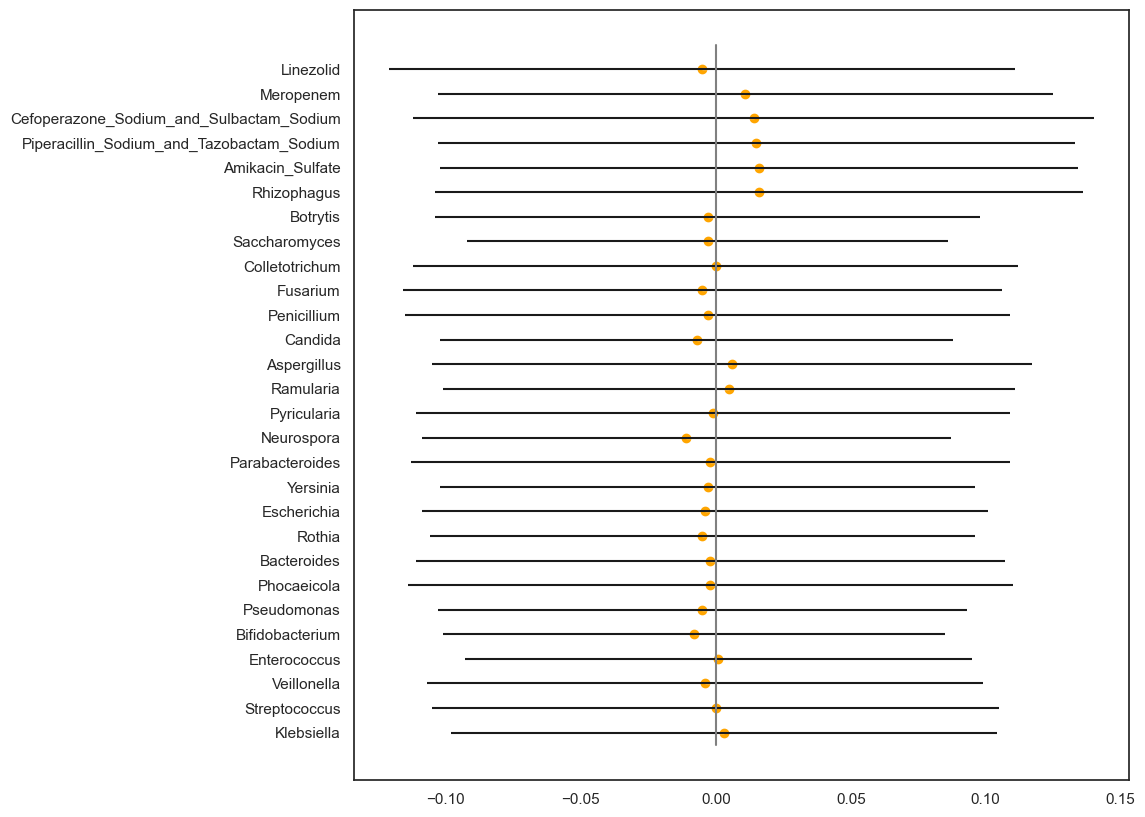

(149, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1321 seconds.
There were 72 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7023587724112593, but should be close to 0.8. Try to increase the number of tuning steps.
There were 203 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Veillonella


<Figure size 640x480 with 0 Axes>

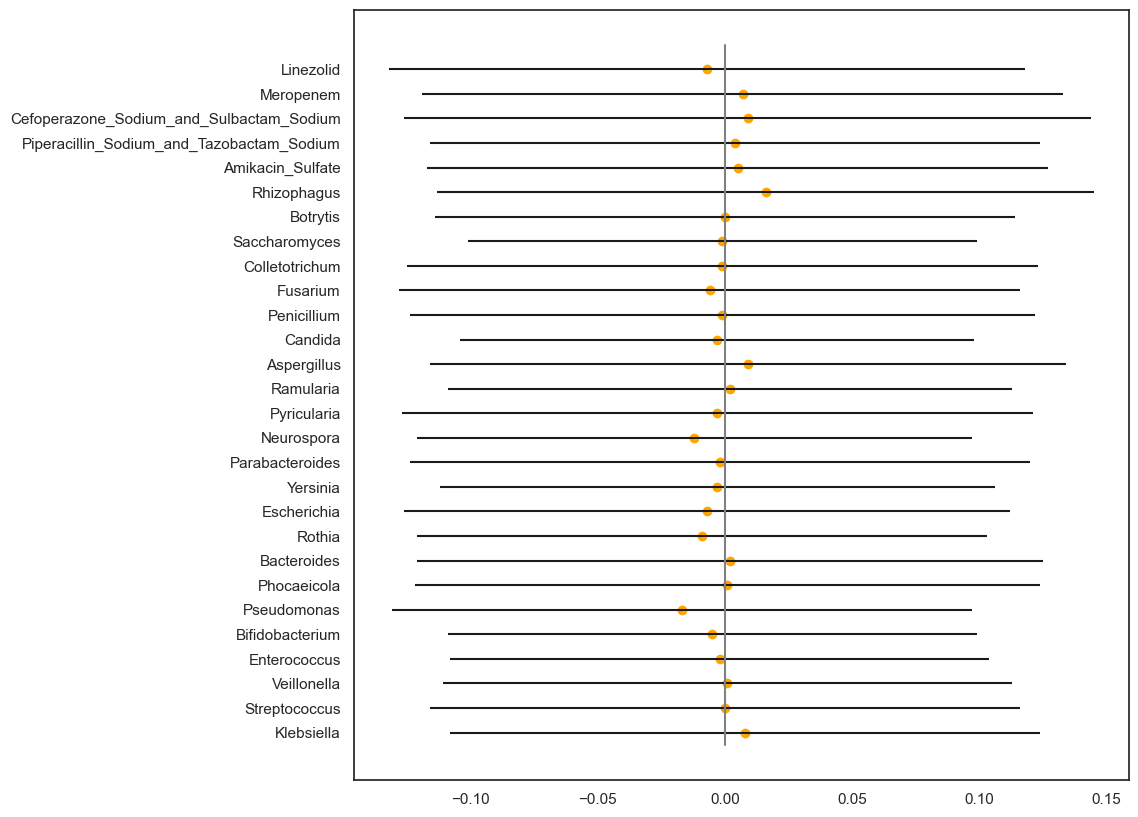

(149, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1245 seconds.
There were 159 divergences after tuning. Increase `target_accept` or reparameterize.
There were 457 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6746360025742175, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Enterococcus


<Figure size 640x480 with 0 Axes>

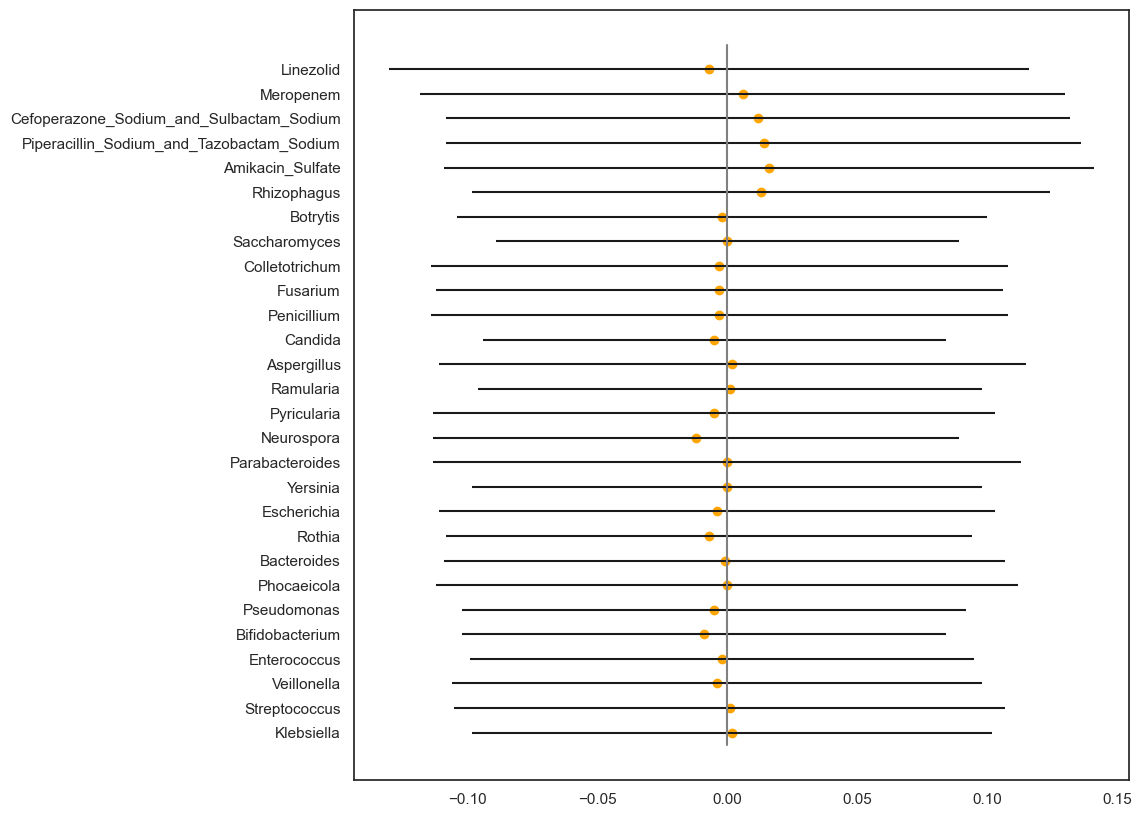

(149, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1312 seconds.
There were 19 divergences after tuning. Increase `target_accept` or reparameterize.
There were 196 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Bifidobacterium


<Figure size 640x480 with 0 Axes>

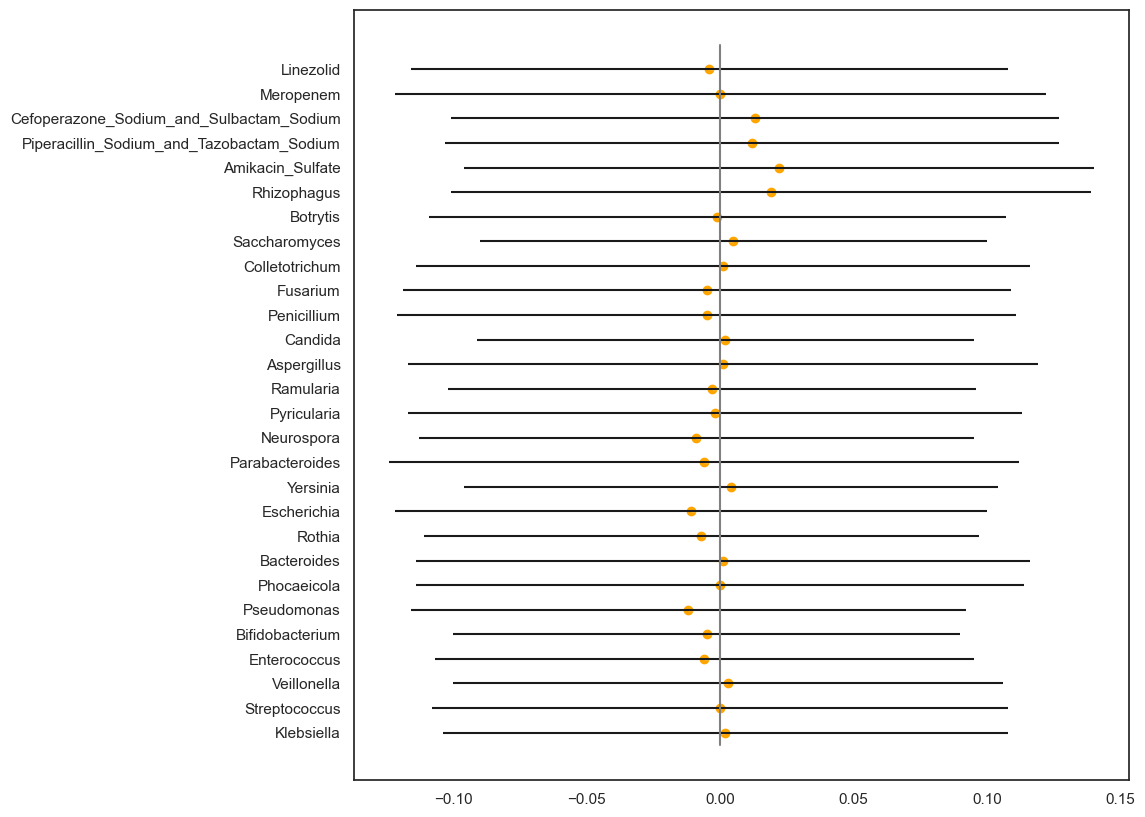

(149, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1203 seconds.
There were 77 divergences after tuning. Increase `target_accept` or reparameterize.
There were 383 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.667404503359745, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Pseudomonas


<Figure size 640x480 with 0 Axes>

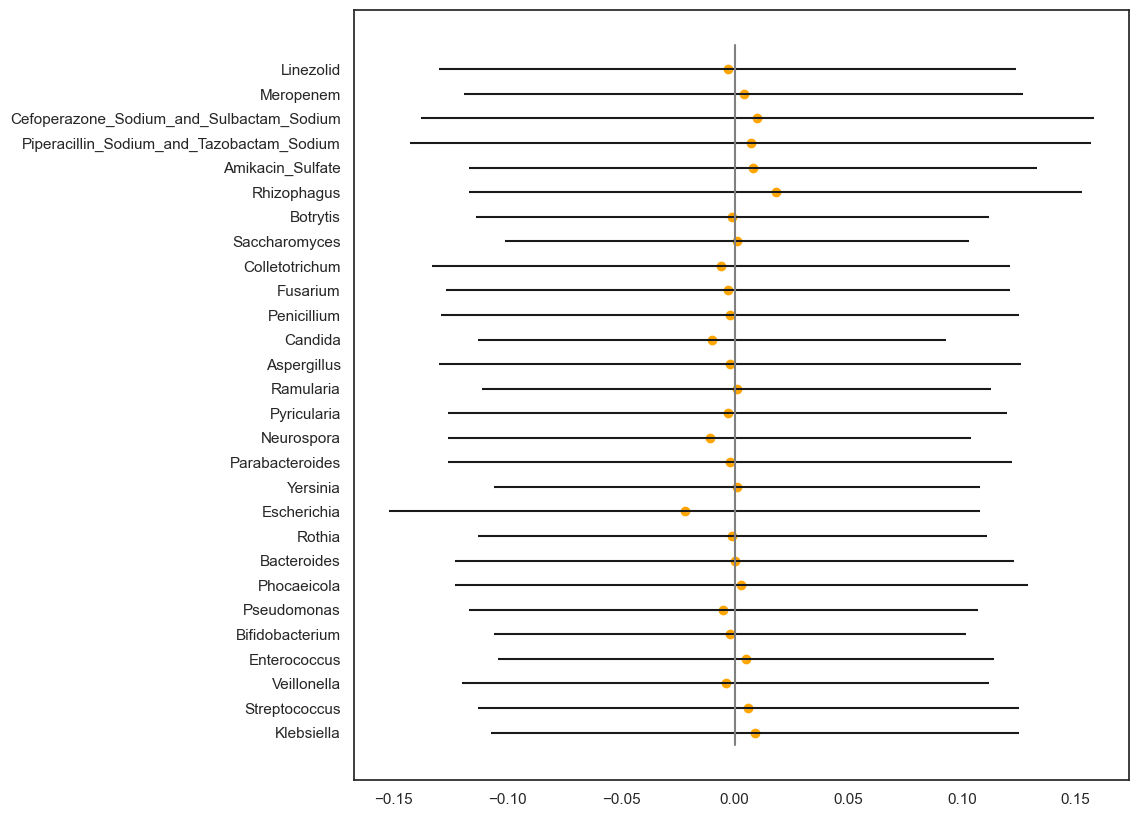

(149, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1260 seconds.
There were 83 divergences after tuning. Increase `target_accept` or reparameterize.
There were 152 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Phocaeicola


<Figure size 640x480 with 0 Axes>

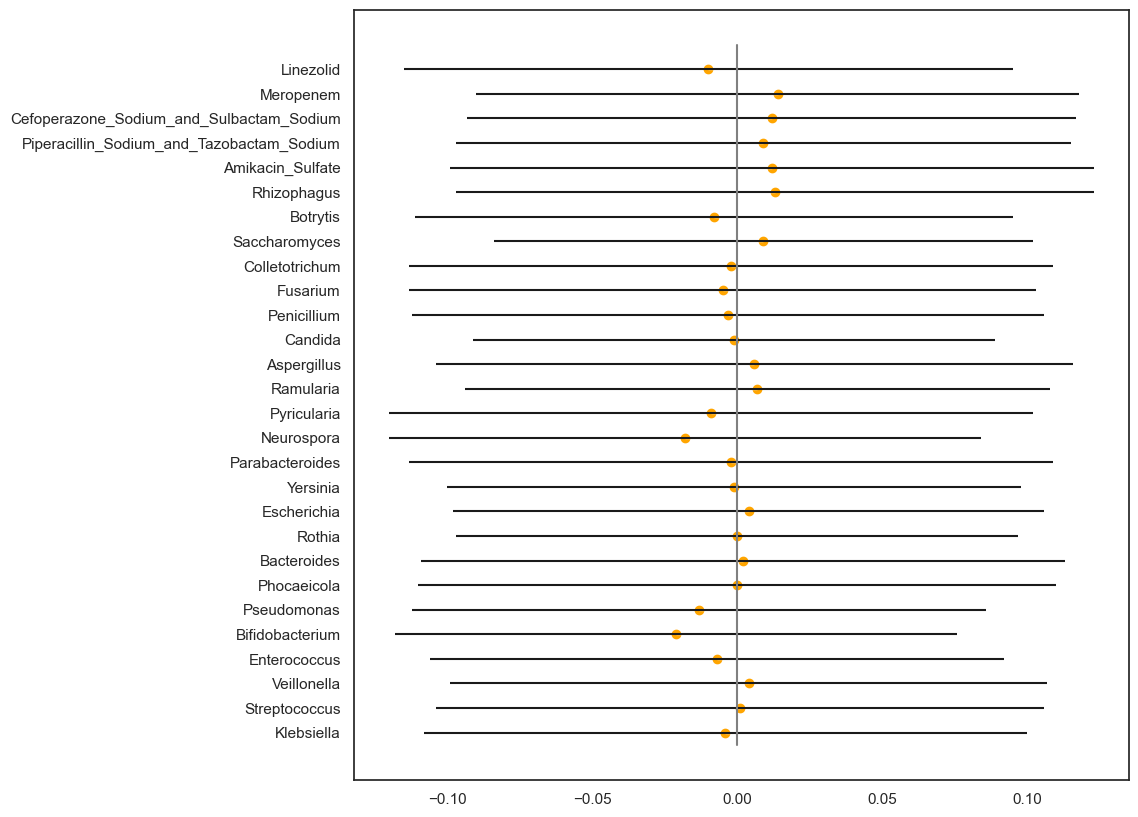

(149, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1278 seconds.
There were 34 divergences after tuning. Increase `target_accept` or reparameterize.
There were 223 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7002949792451599, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Bacteroides


<Figure size 640x480 with 0 Axes>

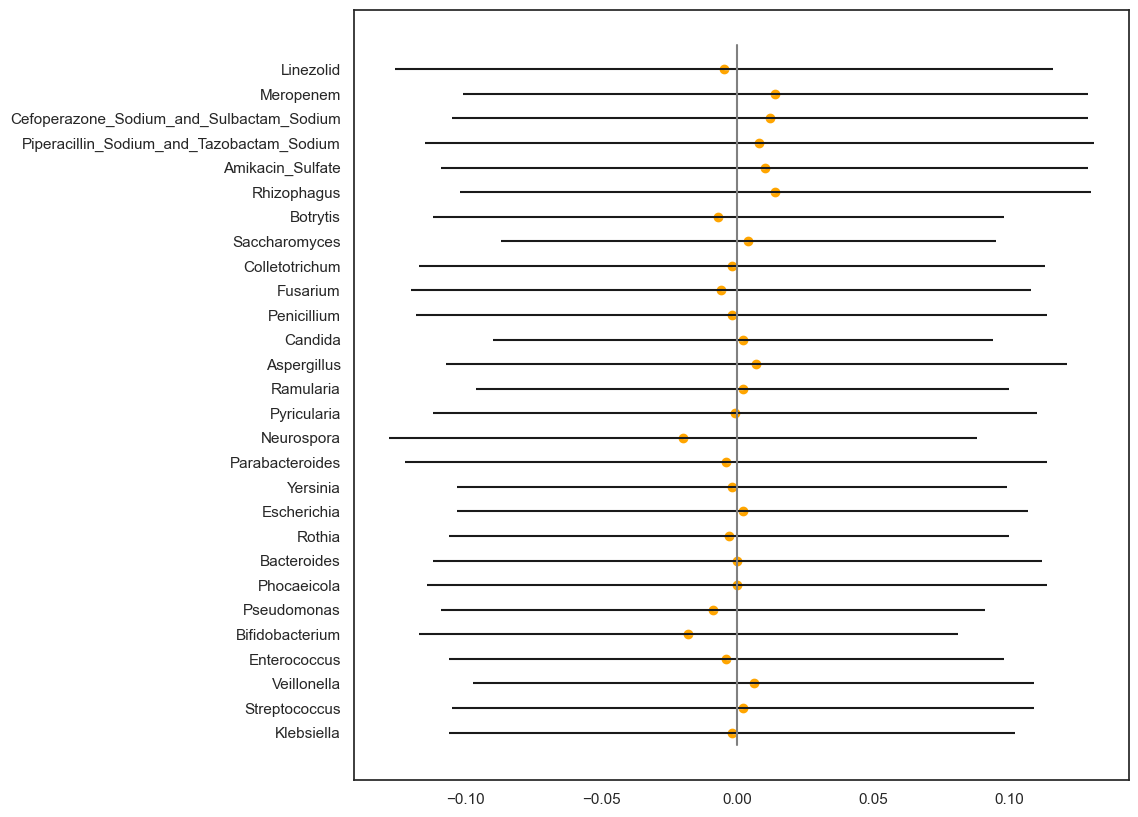

(149, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1222 seconds.
There were 138 divergences after tuning. Increase `target_accept` or reparameterize.
There were 449 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7201571545367252, but should be close to 0.8. Try to increase the number of tuning steps.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Rothia


<Figure size 640x480 with 0 Axes>

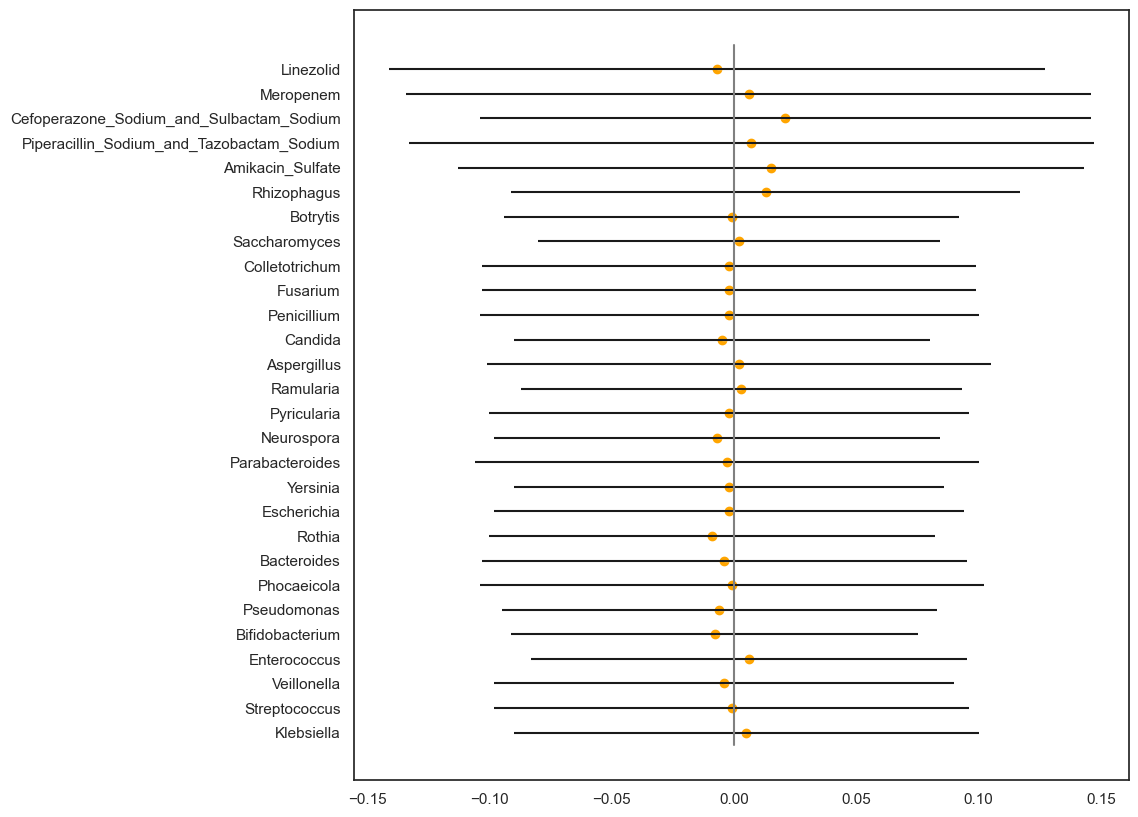

(149, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1211 seconds.
There were 133 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6710284156188453, but should be close to 0.8. Try to increase the number of tuning steps.
There were 266 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Escherichia


<Figure size 640x480 with 0 Axes>

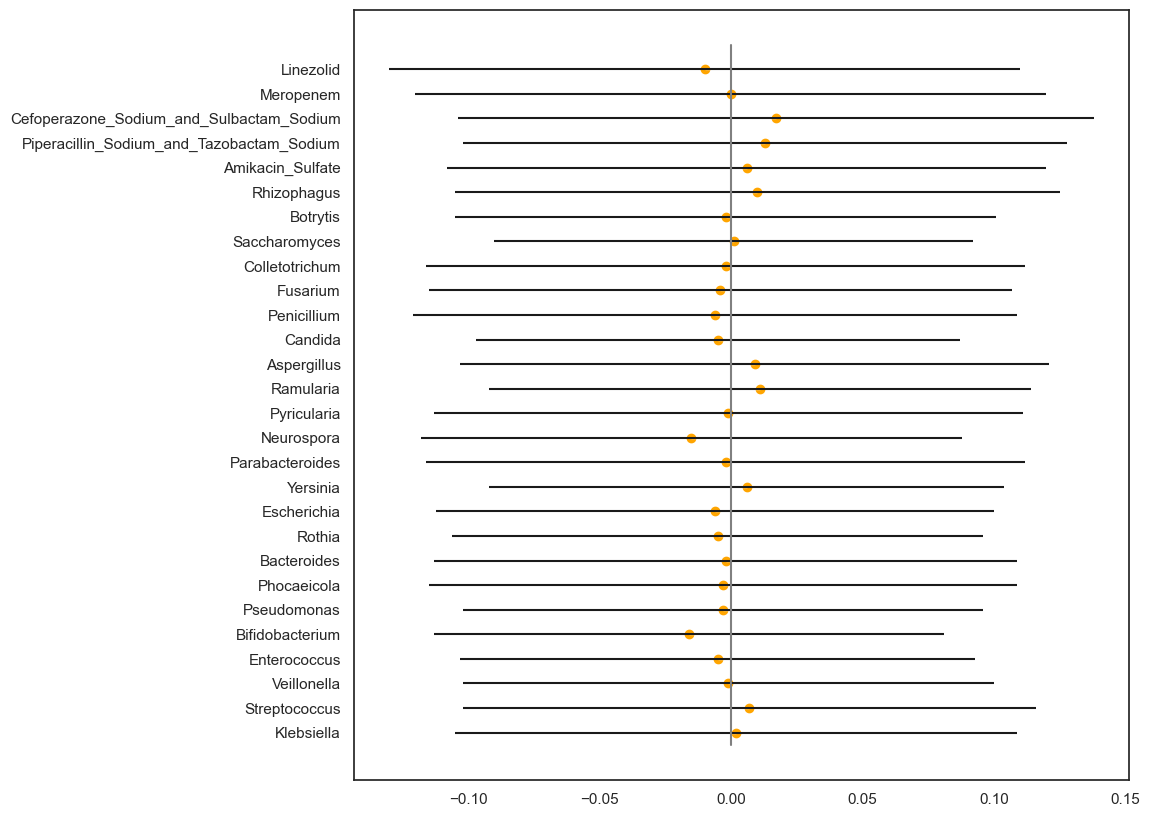

(149, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1195 seconds.
There were 111 divergences after tuning. Increase `target_accept` or reparameterize.
There were 530 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.5402189479266666, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Yersinia


<Figure size 640x480 with 0 Axes>

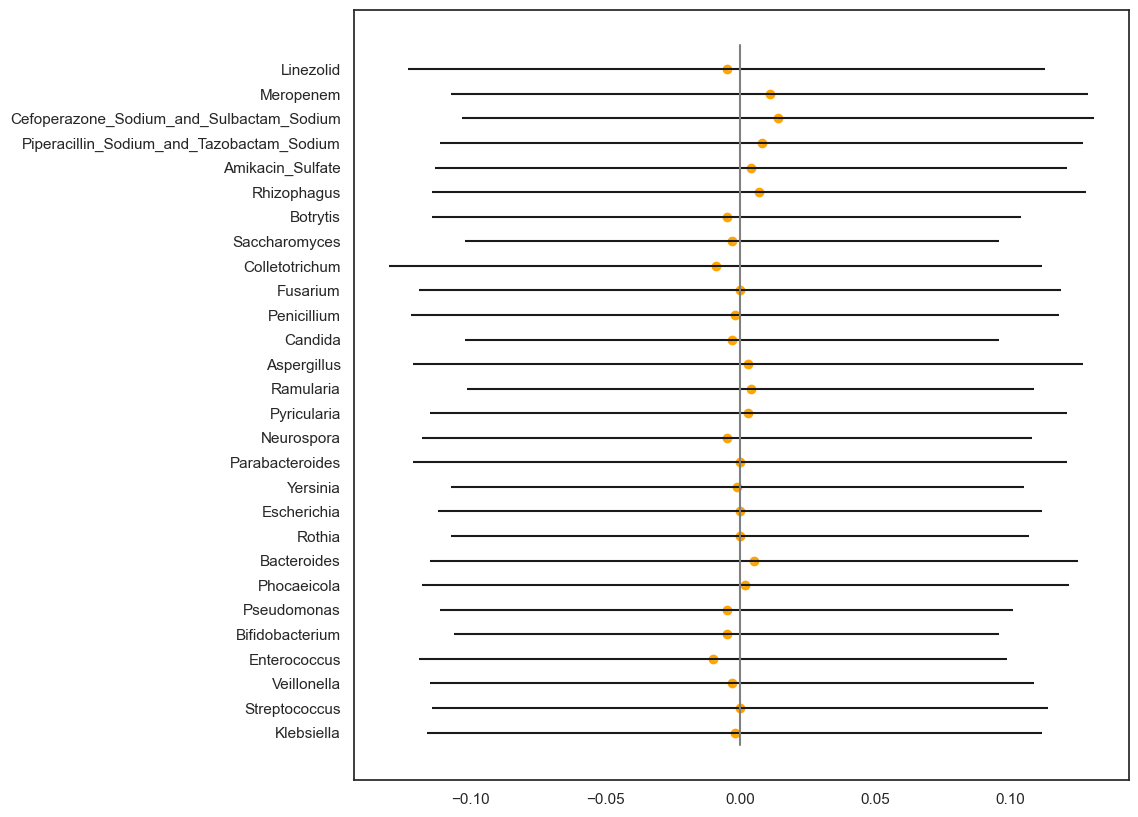

(149, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1186 seconds.
There were 177 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6827048842521772, but should be close to 0.8. Try to increase the number of tuning steps.
There were 526 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6799251377529556, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the mod

Parabacteroides


<Figure size 640x480 with 0 Axes>

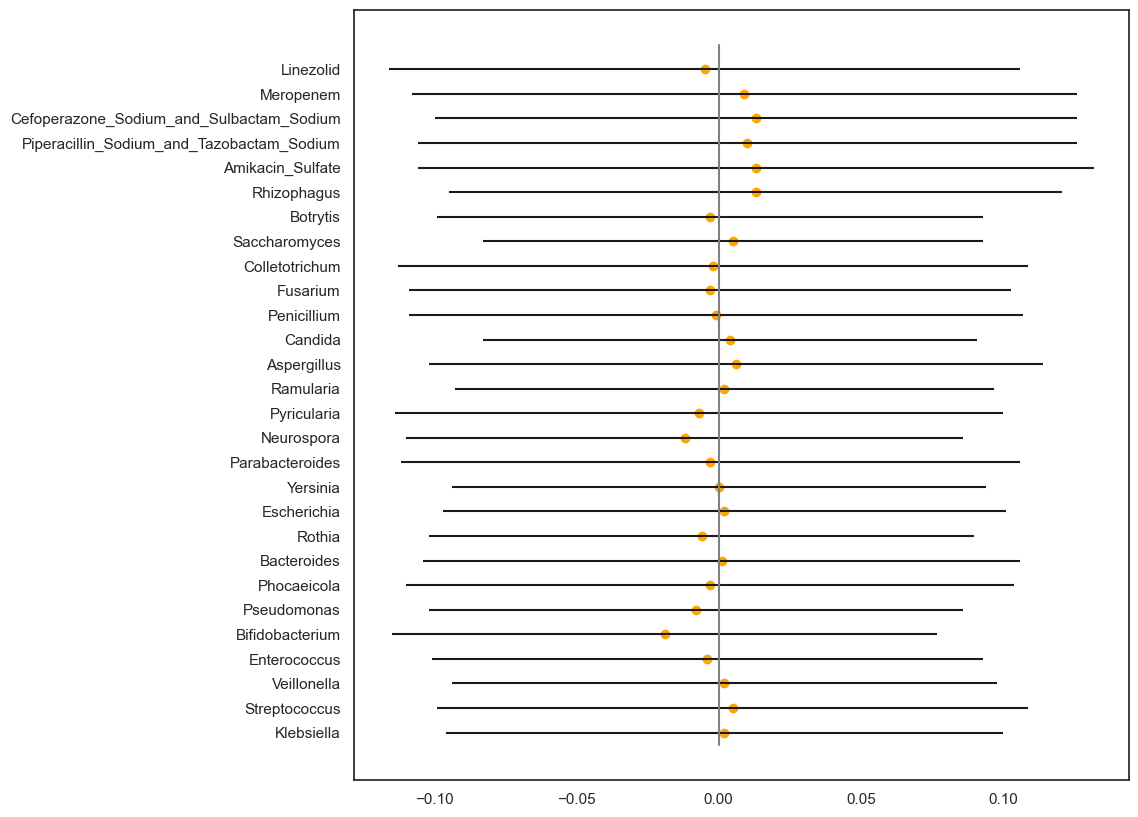

(149, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1252 seconds.
There were 110 divergences after tuning. Increase `target_accept` or reparameterize.
There were 207 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Neurospora


<Figure size 640x480 with 0 Axes>

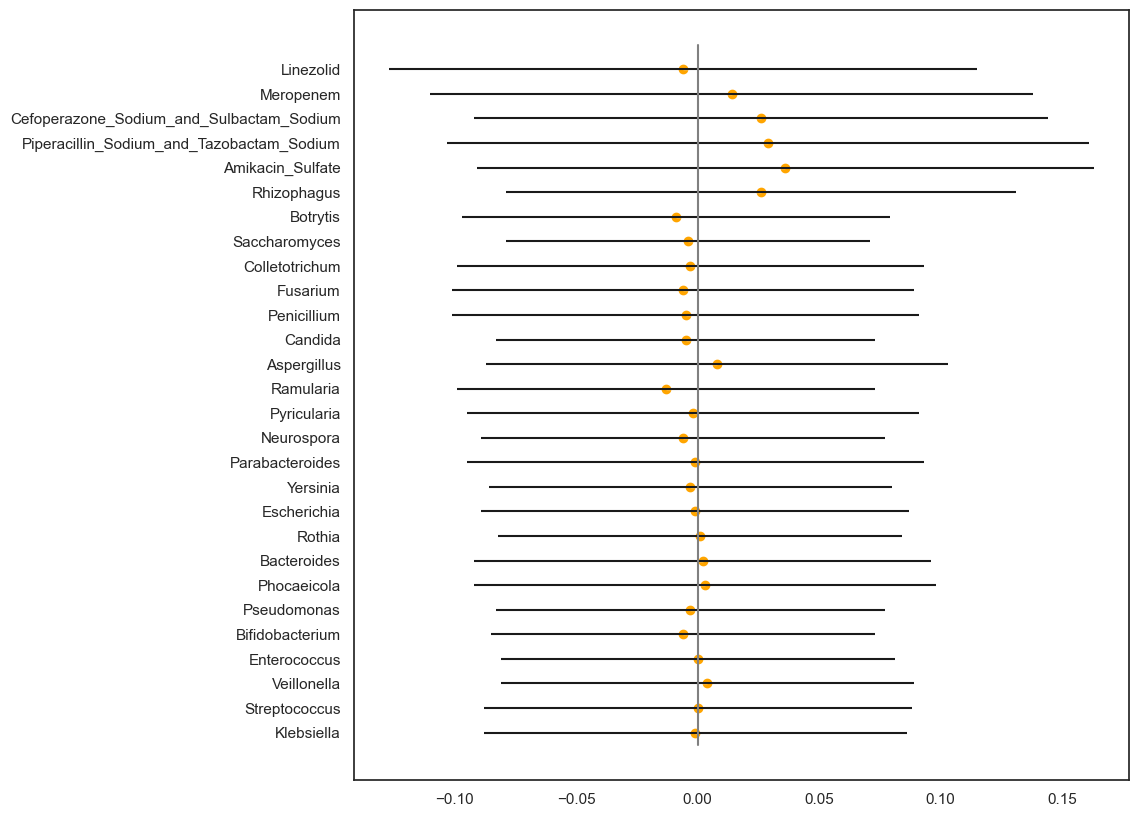

(149, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1320 seconds.
There were 20 divergences after tuning. Increase `target_accept` or reparameterize.
There were 90 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Pyricularia


<Figure size 640x480 with 0 Axes>

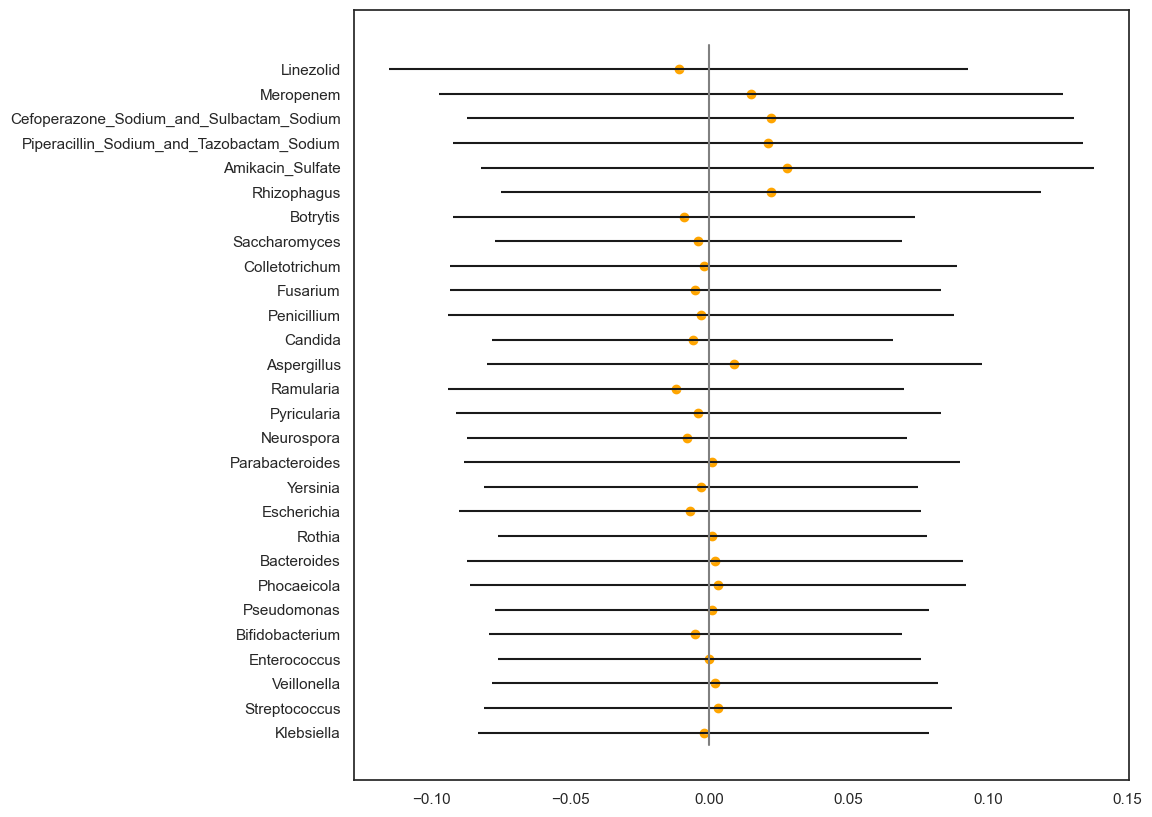

(147, 7)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1301 seconds.
There were 49 divergences after tuning. Increase `target_accept` or reparameterize.
There were 94 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Trichosporon


<Figure size 640x480 with 0 Axes>

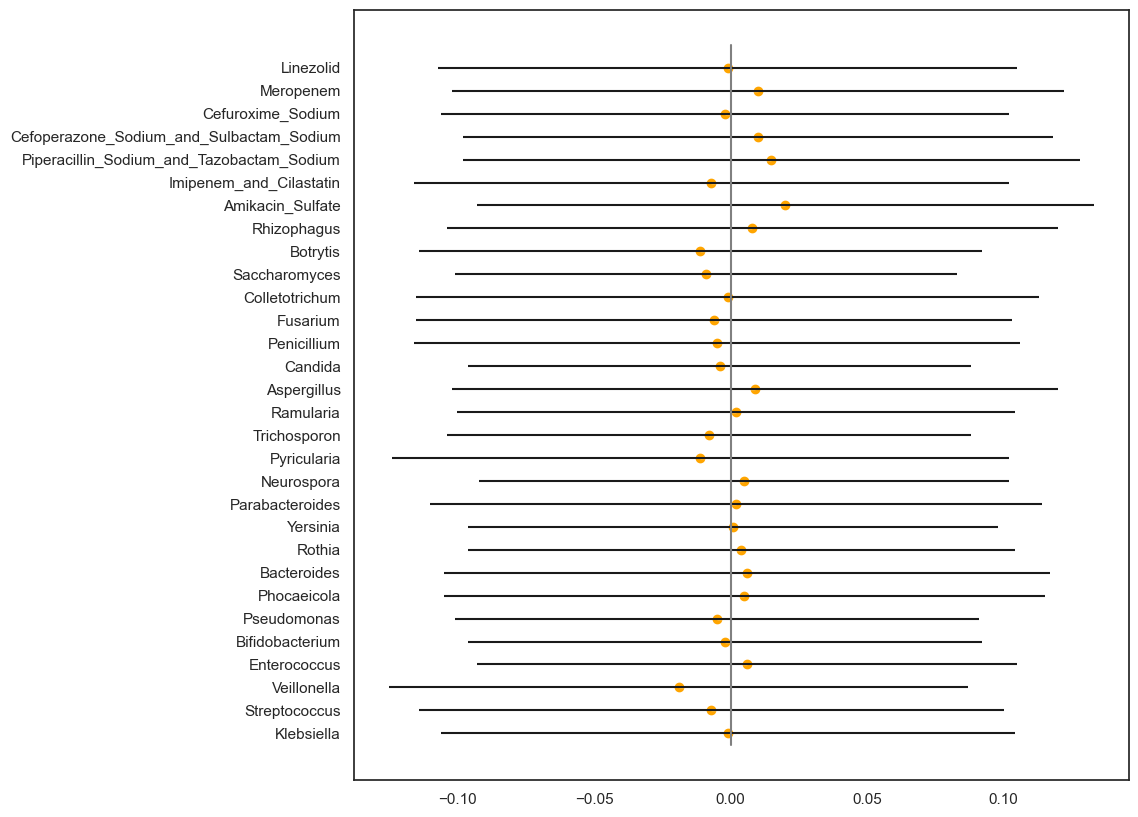

(146, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1246 seconds.
There were 40 divergences after tuning. Increase `target_accept` or reparameterize.
There were 103 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Ramularia


<Figure size 640x480 with 0 Axes>

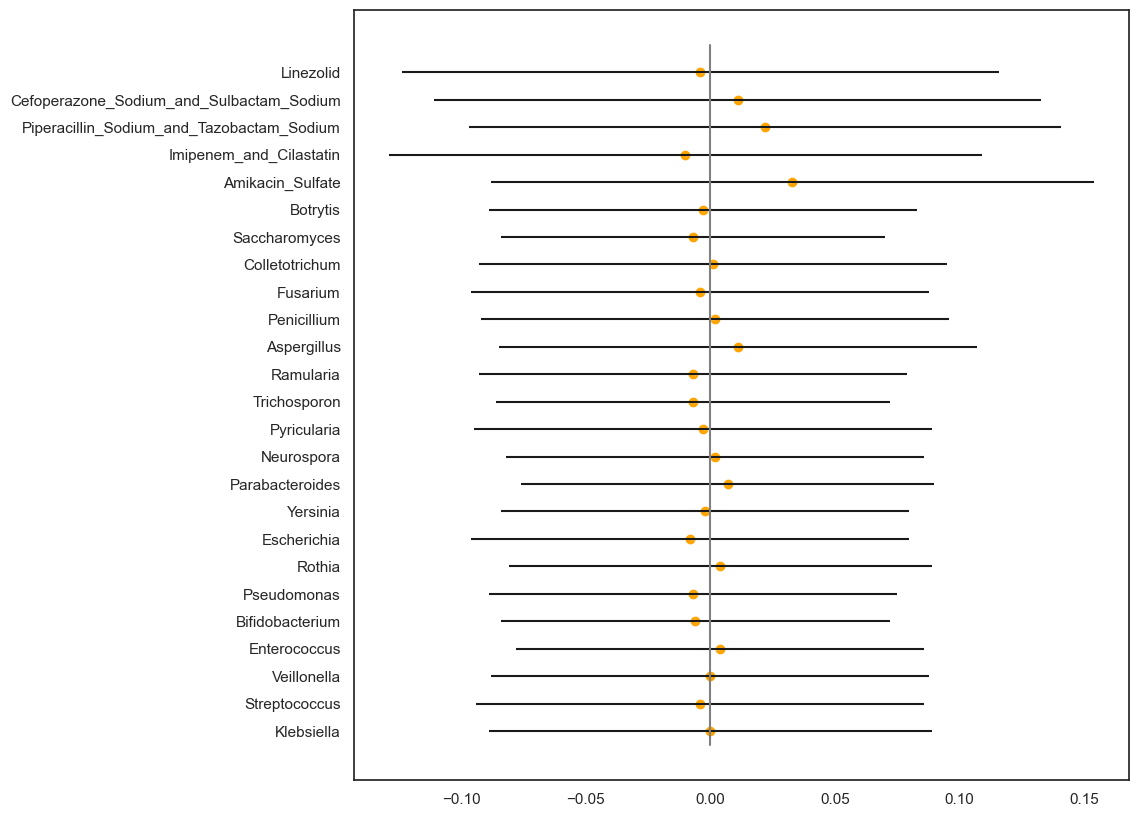

(149, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1147 seconds.
There were 109 divergences after tuning. Increase `target_accept` or reparameterize.
There were 313 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7189504612187476, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Aspergillus


<Figure size 640x480 with 0 Axes>

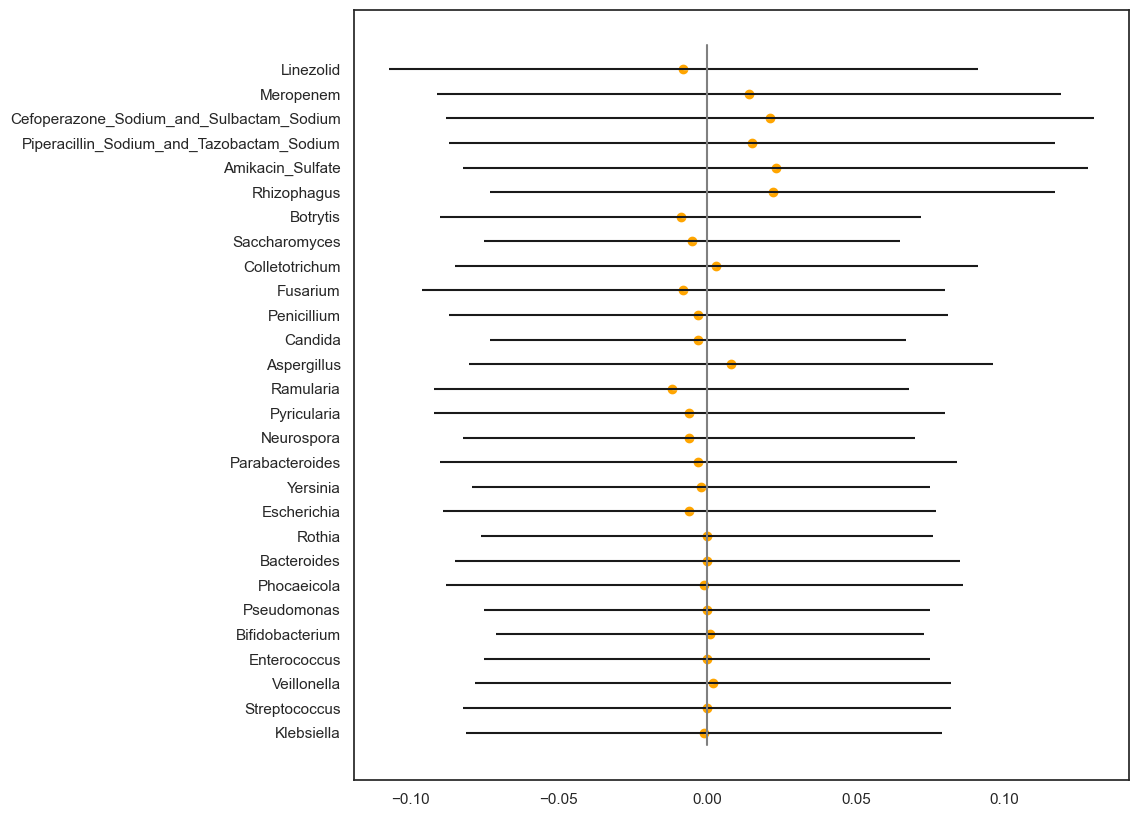

(138, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1253 seconds.
There were 75 divergences after tuning. Increase `target_accept` or reparameterize.
There were 313 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Candida


<Figure size 640x480 with 0 Axes>

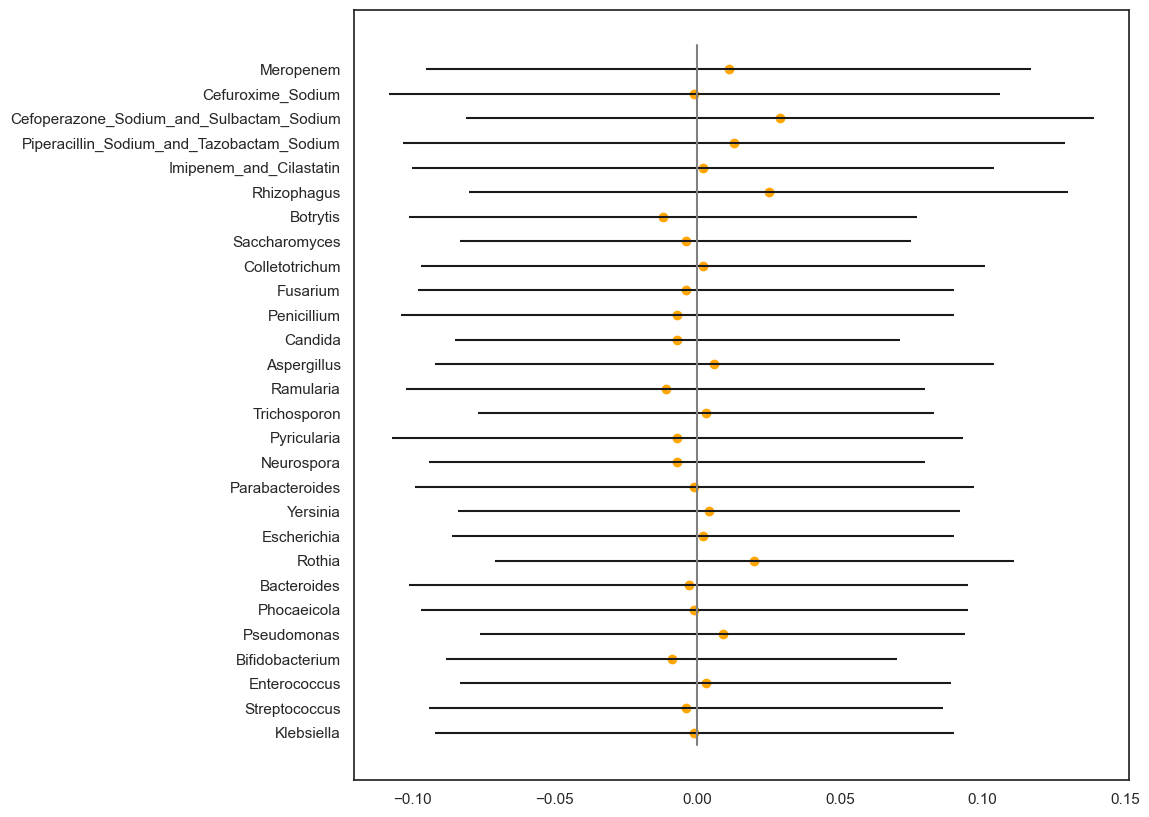

(145, 6)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1062 seconds.
There were 128 divergences after tuning. Increase `target_accept` or reparameterize.
There were 817 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.5440308190209623, but should be close to 0.8. Try to increase the number of tuning steps.
The rhat statistic is larger than 1.05 for some parameters. This indicates slight problems during sampling.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 wit

Penicillium


<Figure size 640x480 with 0 Axes>

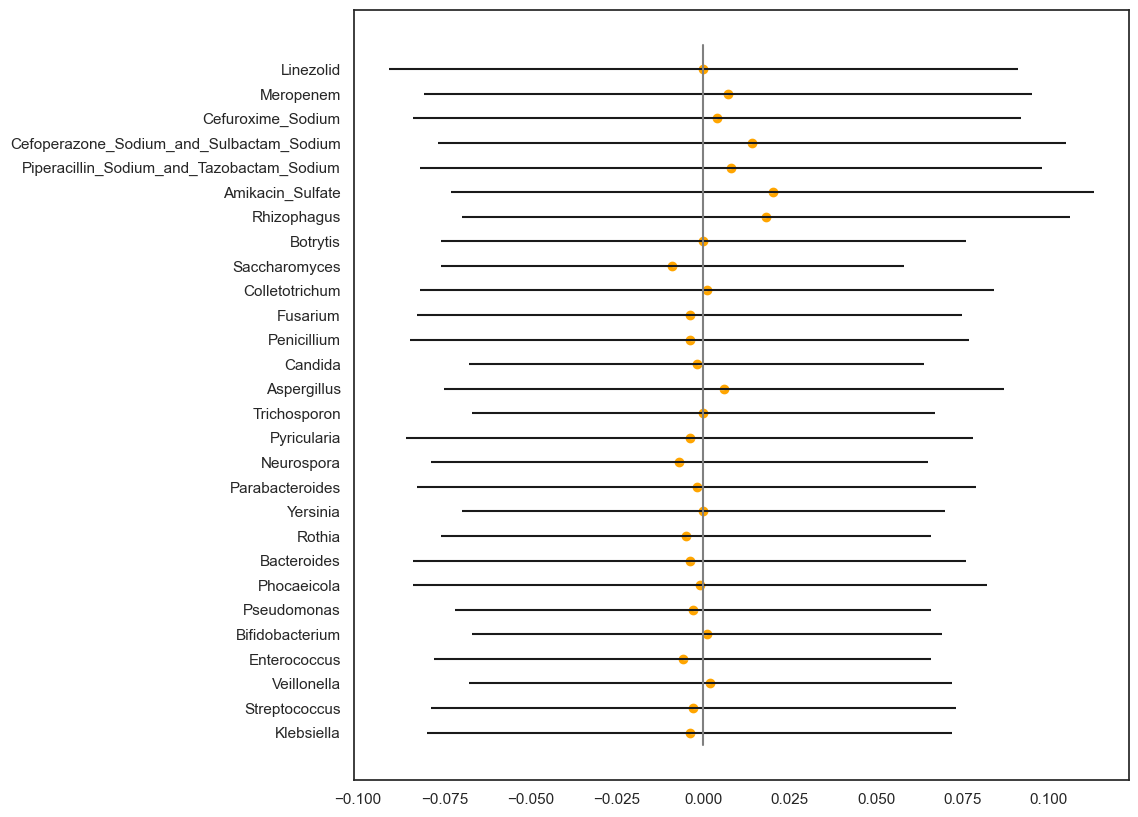

(149, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1142 seconds.
There were 258 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6835862340693185, but should be close to 0.8. Try to increase the number of tuning steps.
There were 329 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Fusarium


<Figure size 640x480 with 0 Axes>

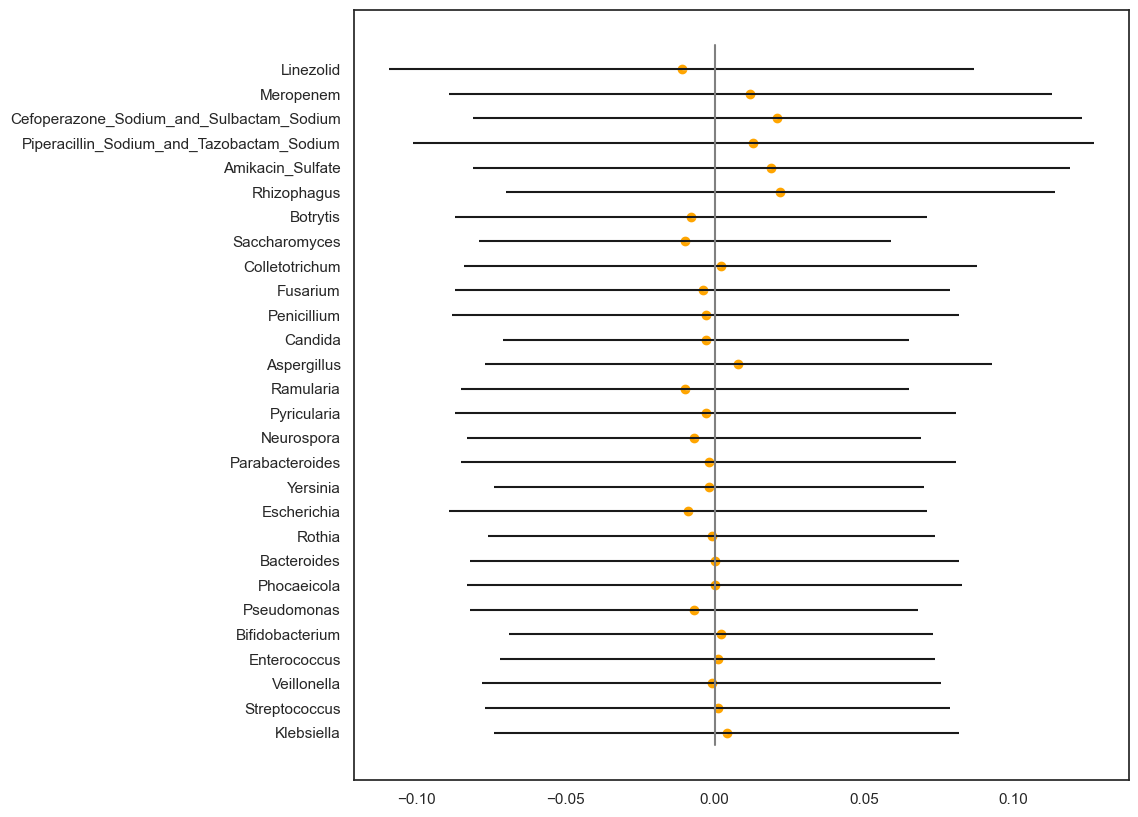

(149, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1333 seconds.
There were 61 divergences after tuning. Increase `target_accept` or reparameterize.
There were 132 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Colletotrichum


<Figure size 640x480 with 0 Axes>

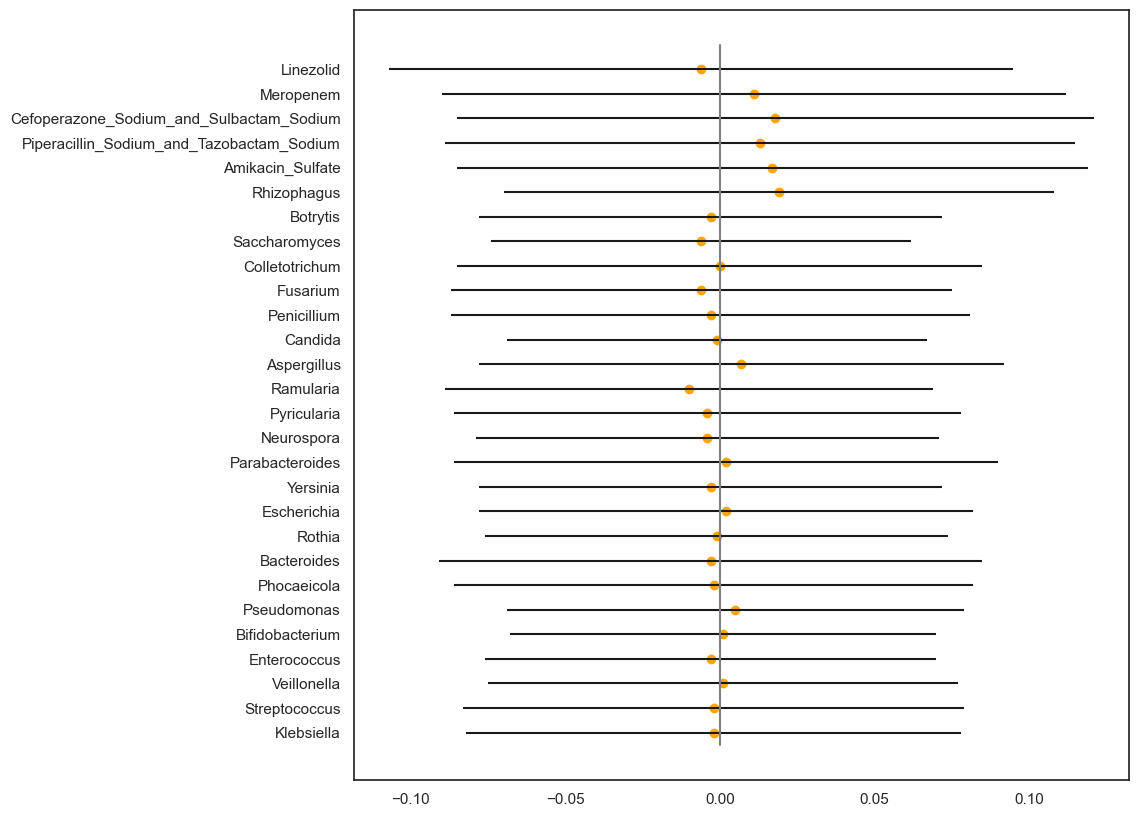

(123, 7)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1258 seconds.
There were 60 divergences after tuning. Increase `target_accept` or reparameterize.
There were 381 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6469917203107647, but should be close to 0.8. Try to increase the number of tuning steps.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Saccharomyces


<Figure size 640x480 with 0 Axes>

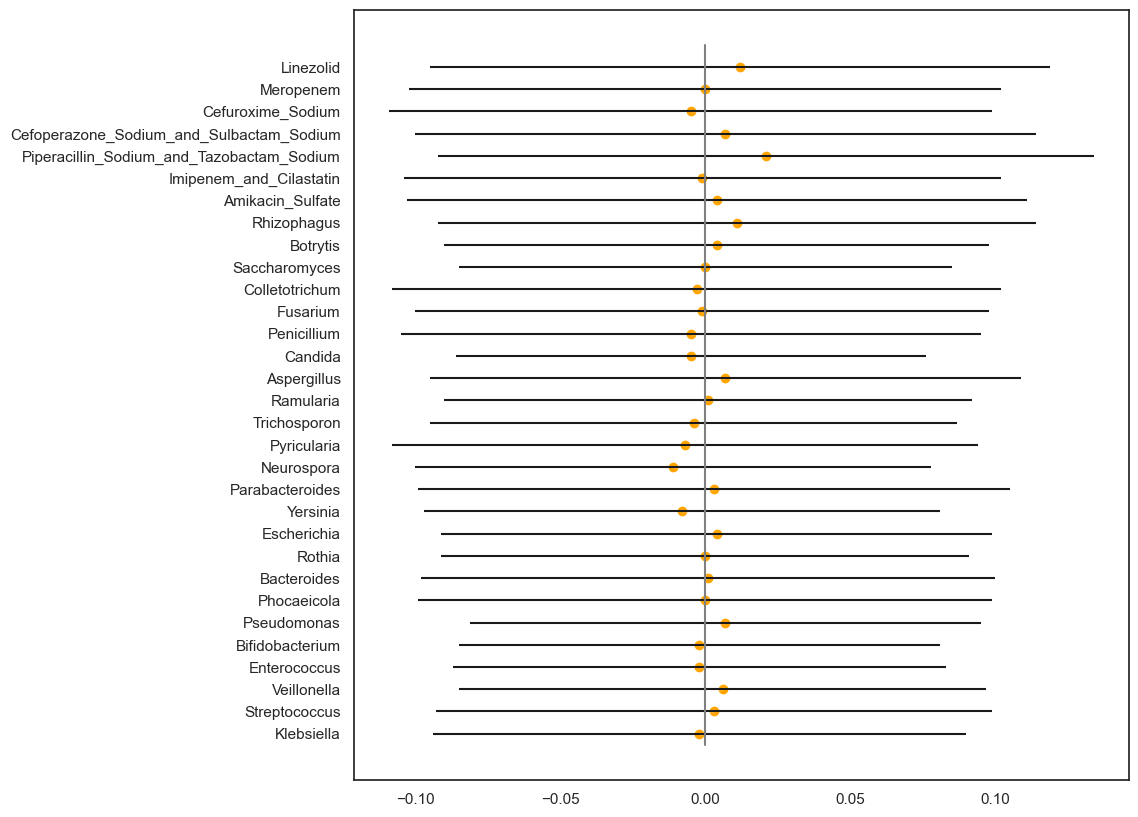

(132, 7)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1257 seconds.
There were 212 divergences after tuning. Increase `target_accept` or reparameterize.
There were 329 divergences after tuning. Increase `target_accept` or reparameterize.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Botrytis


<Figure size 640x480 with 0 Axes>

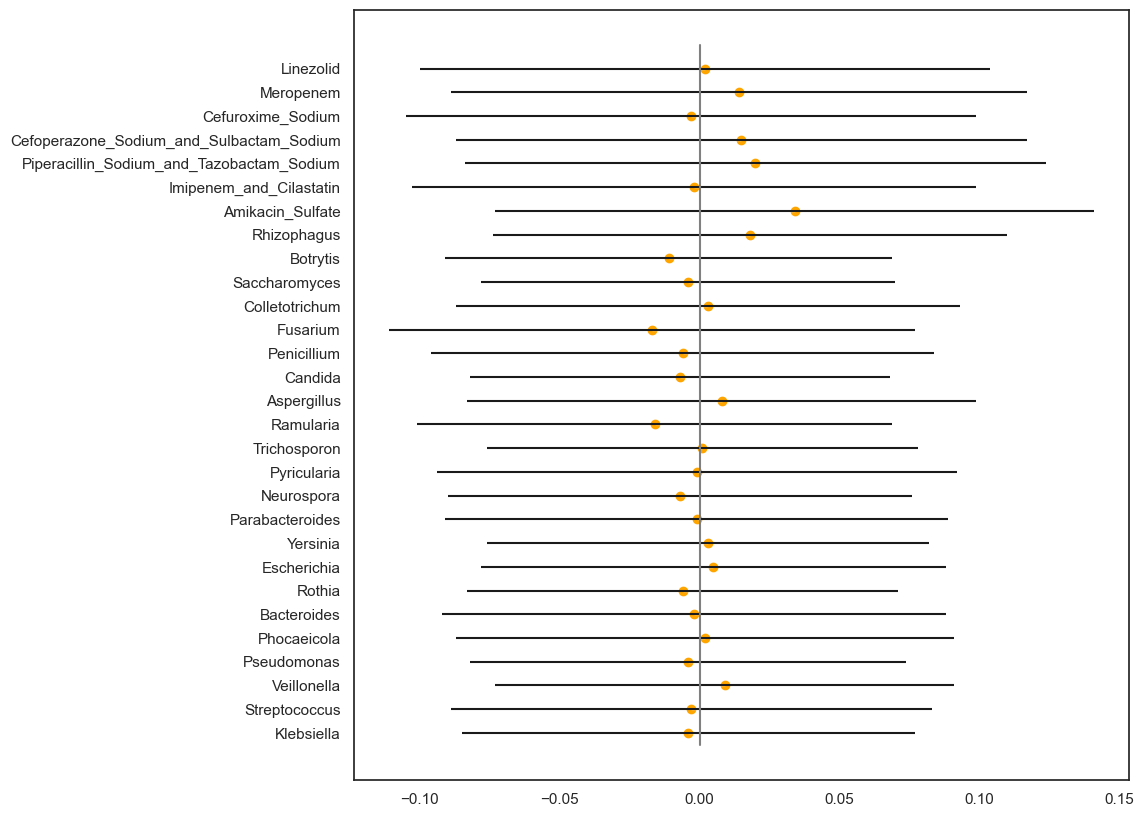

(131, 5)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1142 seconds.
There were 137 divergences after tuning. Increase `target_accept` or reparameterize.
There were 208 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Rhizophagus


<Figure size 640x480 with 0 Axes>

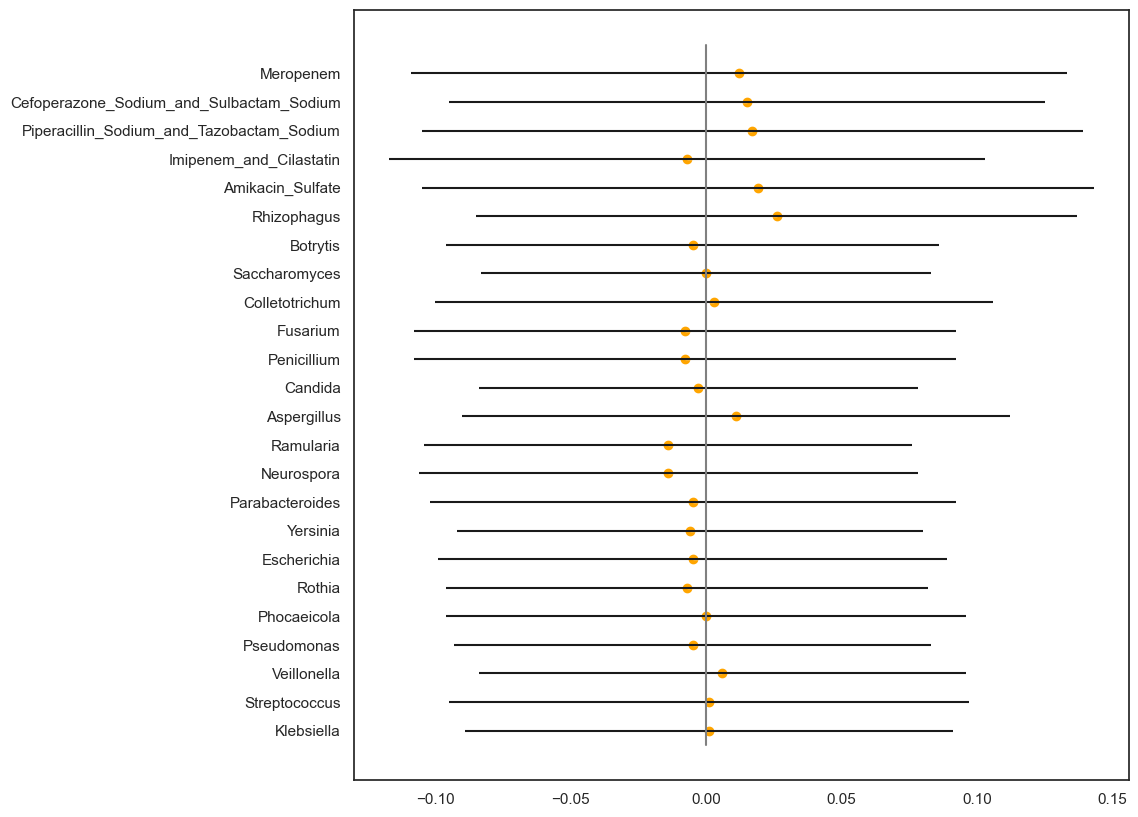

<Figure size 640x480 with 0 Axes>

In [22]:
save_all_X = all_X.copy()
save_all_Y = all_Y.copy()

store_all_interactions = pd.DataFrame()
store_intercepts = pd.DataFrame()

tmp = save_all_X.copy()
tmp[tmp>0]=1

for focal_species in all_Y.columns:
    
    my_all_X = save_all_X.copy()
    my_all_Y = save_all_Y.copy()

    # Drop samples without focal species        
    my_all_X = my_all_X.drop(my_all_X.loc[my_all_X[focal_species] ==0,:].index)
    my_all_Y = my_all_Y.loc[my_all_X.index,:].copy()
    
    # 创建my_all_Y的副本
    my_all_Y_copy = my_all_Y.copy()


    
    if len(my_all_Y) > 10:

        # Standardize all X variables
        tmp = StandardScaler().fit_transform(my_all_X)
        my_all_X = pd.DataFrame(tmp, index = my_all_X.index, columns = my_all_X.columns)
        
        
        model = pm.Model()
 #       X_taxa = my_all_X.copy()[my_all_Y.columns]
        X_taxa = my_all_X.copy()[my_all_Y_copy.columns]
        X_drugs = my_all_X.copy().drop(X_taxa.columns, axis=1)
               
        X_taxa = X_taxa.drop(X_taxa.loc[:,X_taxa.sum()==0].columns,axis=1)
        X_drugs = X_drugs.drop(X_drugs.loc[:,X_drugs.sum()==0].columns,axis=1)

        y = my_all_Y[focal_species].copy()

        
        # Set up priors for model
        
        Sigma_taxa = np.matmul(X_taxa.T.values, X_taxa.values) * 0.5
        Sigma_taxa += np.diag(np.diag(Sigma_taxa))
        Sigma_taxa = np.linalg.inv(Sigma_taxa)
        #Sigma_taxa = np.identity(len(Sigma_taxa)) # alternatively use identity matrix (results same)
        
        Sigma_drugs = np.matmul(X_drugs.T.values, X_drugs.values) * 0.5
        Sigma_drugs += np.diag(np.diag(Sigma_drugs))
        Sigma_drugs = np.linalg.inv(Sigma_drugs)
        #Sigma_drugs = np.identity(len(Sigma_drugs)) # alternatively use identity matrix (results same)
        
        # For calculating growth rate initialisation
        X_growth = my_all_X.copy()
        X_growth = sm.add_constant(X_growth)
        Y = my_all_Y[focal_species].copy()
        r_model = sm.OLS(Y,X_growth)
    
        results = r_model.fit()
        init_r = results.params['const']
        if init_r < 0:
            init_r = 0
            
        init_r_std= np.std(results.params) # inflate initial prior for intercept
    
        
        with pm.Model() as model:
            
            xi_taxa = pm.Bernoulli('xi_taxa', .5, shape=X_taxa.shape[1])
            tau_taxa = pm.HalfCauchy('tau_taxa', 1)
            beta_taxa = pm.MvNormal('beta_taxa', 0, tau_taxa * Sigma_taxa, shape=X_taxa.shape[1])
            mean_taxa = pm.math.dot(X_taxa, xi_taxa * beta_taxa)
            # 检查 X_drugs 的形状
            print(X_drugs.shape)

            # 在使用之前确保 X_drugs 具有有效的形状
            if X_drugs.shape[1] <= 0:
                raise ValueError("X_drugs 的形状无效。请检查数据或计算。")
 

            xi_drugs = pm.Bernoulli('xi_drugs', .5, shape=X_drugs.shape[1])
            tau_drugs = pm.HalfCauchy('tau_drugs', 1)
            beta_drugs = pm.MvNormal('beta_drugs', 0, tau_drugs * Sigma_drugs, shape=X_drugs.shape[1])
            mean_drugs = pm.math.dot(X_drugs, xi_drugs * beta_drugs)
            
            my_sigma = pm.HalfNormal('my_sigma', 10) 

            
            intercp = pm.Bound(pm.Normal, lower=0.0)('intercp', mu=1.0, tau=(init_r_std**2)*1e2)
            
            my_var = pm.Normal('my_var', mean_drugs + mean_taxa + intercp, my_sigma, observed=y)

            lasso_normal_trace_s = pm.sample(draws =10000,tune=2500, init='adapt_diag', cores=-1)



        my_summary = pm.summary(lasso_normal_trace_s)
        
        store_intercepts.loc[focal_species, 'ic'] = my_summary.loc['intercp','mean']
        
        new_summary = pd.DataFrame()
        for ix, val in enumerate(X_taxa.columns):
            #cur_index = 'beta_taxa__' + str(ix)
            cur_index = 'beta_taxa[' + str(ix) + ']'
            cur_mean = my_summary.loc[cur_index, 'mean']
            cur_sd = my_summary.loc[cur_index, 'sd']
            try:
                rename_val = val + '_' + otu_table.loc[val, 'family']
            except:
                rename_val = val
            new_summary.loc[rename_val, 'cur_mean'] = cur_mean
            new_summary.loc[rename_val, 'cur_sd'] = cur_sd
            store_all_interactions.loc[focal_species, val] = cur_mean



        for ix, val in enumerate(X_drugs.columns):
            #cur_index = 'beta_drugs__' + str(ix)
            cur_index = 'beta_drugs[' + str(ix) + ']'
            cur_mean = my_summary.loc[cur_index, 'mean']
            cur_sd = my_summary.loc[cur_index, 'sd']
            try:
                rename_val = val + '_' + otu_table.loc[val, 'family']
            except:
                rename_val = val
            new_summary.loc[rename_val, 'cur_mean'] = cur_mean
            new_summary.loc[rename_val, 'cur_sd'] = cur_sd
            store_all_interactions.loc[focal_species, val] = cur_mean


        try:
            print(focal_species, otu_table.loc[focal_species, 'family'])
        except:
            print(focal_species)
        sns.set_style('white')
        plt.figure(figsize=(10,10))

        plt.scatter(x = new_summary.cur_mean, y = new_summary.index, c='orange')
        plt.barh(y = new_summary.index,
                width = new_summary.cur_mean,
                height=0.0,
                xerr= new_summary.cur_sd)
        plt.plot([0,0],[-0.5,len(new_summary)+0.0],'gray')
        plt.savefig(f'E:/projects/肝移植/fig3/glv/figure/w/{focal_species}.pdf', format='pdf')
        plt.show()
        plt.clf()
    
   # break

In [117]:
#st.write_file('./all_interactions.txt', store_all_interactions)

In [23]:
store_all_interactions.to_csv('E:/projects/肝移植/fig3/glv/figure/w/all_interactions.txt', sep='\t')

In [3]:
store_all_interactions = pd.read_table('E:/projects/肝移植/fig3/glv/w/all_interactions.txt',sep='\t',index_col=0)

In [4]:
store_all_interactions

,Klebsiella,Streptococcus,Veillonella,Enterococcus,Bifidobacterium,Pseudomonas,Phocaeicola,Bacteroides,Rothia,Escherichia,...,Botrytis,Rhizophagus,Amikacin_Sulfate,Piperacillin_Sodium_and_Tazobactam_Sodium,Cefoperazone_Sodium_and_Sulbactam_Sodium,Meropenem,Linezolid,Trichosporon,Imipenem_and_Cilastatin,Cefuroxime_Sodium
Klebsiella,0.004,0.005,-0.011,0.008,0.001,-0.007,0.002,0.011,-0.001,-0.001,...,-0.016,0.014,0.012,0.058,0.062,0.023,0.026,NaN,NaN,NaN
Streptococcus,0.003,-0.000,-0.004,0.001,-0.008,-0.005,-0.002,-0.002,-0.005,-0.004,...,-0.003,0.016,0.016,0.015,0.014,0.011,-0.005,NaN,NaN,NaN
Veillonella,0.008,0.000,0.001,-0.002,-0.005,-0.017,0.001,0.002,-0.009,-0.007,...,-0.000,0.016,0.005,0.004,0.009,0.007,-0.007,NaN,NaN,NaN
Enterococcus,0.002,0.001,-0.004,-0.002,-0.009,-0.005,0.000,-0.001,-0.007,-0.004,...,-0.002,0.013,0.016,0.014,0.012,0.006,-0.007,NaN,NaN,NaN
Bifidobacterium,0.002,0.000,0.003,-0.006,-0.005,-0.012,-0.000,0.001,-0.007,-0.011,...,-0.001,0.019,0.022,0.012,0.013,0.000,-0.004,NaN,NaN,NaN
Pseudomonas,0.009,0.006,-0.004,0.005,-0.002,-0.005,0.003,0.000,-0.001,-0.022,...,-0.001,0.018,0.008,0.007,0.010,0.004,-0.003,NaN,NaN,NaN
Phocaeicola,-0.004,0.001,0.004,-0.007,-0.021,-0.013,0.000,0.002,0.000,0.004,...,-0.008,0.013,0.012,0.009,0.012,0.014,-0.010,NaN,NaN,NaN
Bacteroides,-0.002,0.002,0.006,-0.004,-0.018,-0.009,0.000,0.000,-0.003,0.002,...,-0.007,0.014,0.010,0.008,0.012,0.014,-0.005,NaN,NaN,NaN
Rothia,0.005,-0.001,-0.004,0.006,-0.008,-0.006,-0.001,-0.004,-0.009,-0.002,...,-0.001,0.013,0.015,0.007,0.021,0.006,-0.007,NaN,NaN,NaN
Escherichia,0.002,0.007,-0.001,-0.005,-0.016,-0.003,-0.003,-0.002,-0.005,-0.006,...,-0.002,0.010,0.006,0.013,0.017,0.000,-0.010,NaN,NaN,NaN


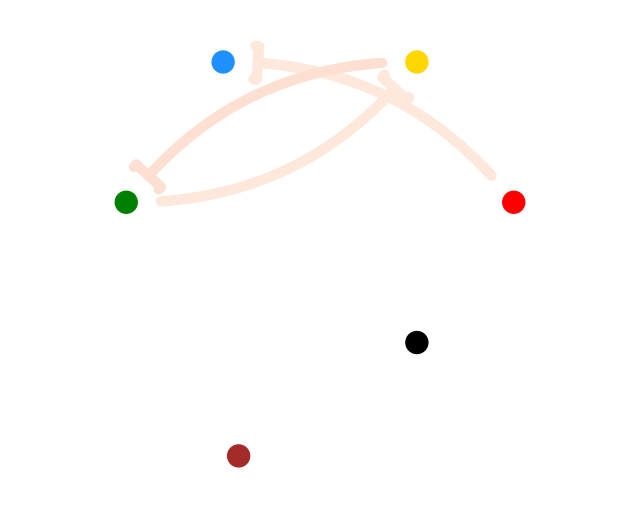

In [5]:
### Plot positive edges ###
#G=nx.from_numpy_matrix(np.array(cm_pos),
#                       create_using=nx.MultiDiGraph())
f, ax = plt.subplots(1,figsize=(8, 6.5))
my_list = ['Veillonella',
            'Bifidobacterium',
    
           'Klebsiella',
        'Escherichia',
           'Streptococcus','Candida']
### Split interactions into positive and negative for plotting ###
cur_matrix = store_all_interactions.copy()
cur_matrix[abs(cur_matrix) <0.01]=0 # filter out very weak interactions
cur_matrix = cur_matrix.loc[my_list, my_list].T
cm_pos = cur_matrix.copy()
cm_pos[cm_pos<0]=0
cm_neg = cur_matrix.copy()
cm_neg[cm_neg>0]=0
import networkx as nx
G=nx.from_numpy_array(np.array(cm_pos),
                       create_using=nx.MultiDiGraph())

pos = nx.layout.circular_layout(G)
pos[4] = (pos[4][0] + 0.08, pos[4][1]-0.7)

M = G.number_of_edges()
edge_colors = np.zeros(M)
for ix, e in enumerate(G.edges(data=True)):
    edge_colors[ix] = abs(e[2]['weight'])

for cix, cn in enumerate(G.edges()):
    e = FancyArrowPatch(pos[cn[0]],
                        pos[cn[1]],
                            arrowstyle='-|>',
                            connectionstyle='arc3,rad=0.25',
                            mutation_scale=35.0,
                            lw=7.5,
                            color=cm.Blues(edge_colors[cix]*5),
                            shrinkA=25,
                            shrinkB=25)
    ax.add_patch(e)

    
### Plot negative edges ###
#G=nx.from_numpy_matrix(np.array(cm_neg),
#                      create_using=nx.MultiDiGraph())
G=nx.from_numpy_array(np.array(cm_neg),
                       create_using=nx.MultiDiGraph())

M = G.number_of_edges()
edge_colors = np.zeros(M)
for ix, e in enumerate(G.edges(data=True)):
    edge_colors[ix] = abs(e[2]['weight'])

for cix, cn in enumerate(G.edges()):
    e = FancyArrowPatch(pos[cn[0]],
                        pos[cn[1]],
                            arrowstyle='-[',
                            connectionstyle='arc3,rad=0.25',
                            mutation_scale=12.0,
                            lw=7.5,
                            color=cm.Reds(edge_colors[cix]*8),
                            shrinkA=25,
                            shrinkB=25)
    ax.add_patch(e)


### Plot nodes ###
node_colors = ['red', 'gold','dodgerblue', 'green', 'brown','black']
nx.draw_networkx_nodes(G,pos,nodelist=range(6),node_shape='o', node_size=250, node_color= node_colors[0:6])
#nx.draw_networkx_nodes(G,pos,nodelist=[3],node_shape='o', node_size=250, node_color=['brown'])
    
    
### Fix axis ###
ax.set_xlim([-1.1,1.1])
ax.set_ylim([-1.1,1.1])
plt.axis('off')
plot_margin = 0.5
x0, x1, y0, y1 = plt.axis()
plt.axis((x0 - plot_margin,
          x1 + plot_margin,
          y0 -plot_margin-0.3,
          y1 + 0.09))

#plt.savefig("E:/projects/肝移植/fig3/glv/new/w.g.ca.pdf", format="pdf", bbox_inches='tight')  # 导出为PDF
plt.show()

#print("图形已保存为output_plot.pdf")

In [30]:
# Get antimicrobial interactions
abx_matrix = store_all_interactions.copy()
abx_matrix = abx_matrix.drop(my_bacteria,axis=1)
#abx_matrix = abx_matrix.drop(my_fungi,axis = 1).fillna(0)
#abx_matrix[abs(abx_matrix) < 0.001] = 0

In [31]:
## Split up antimicrobial matrix
# bacteria / antibiotics
#bac_abx = abx_matrix.loc[my_bacteria,antibacterials].copy().dropna(1)
bac_abx = abx_matrix.copy().dropna()
store_abx_tmp = pd.DataFrame()
for col in bac_abx.columns:
    tmp = bac_abx.loc[:,col]
    #store_abx_tmp = pd.concat([store_abx_tmp, pd.DataFrame(tmp[tmp! = 0].get_values())])
    store_abx_tmp = pd.concat([store_abx_tmp, pd.DataFrame(tmp[tmp!=0].to_numpy())])
store_abx_tmp = store_abx_tmp.reset_index().drop(['index'], axis = 1)

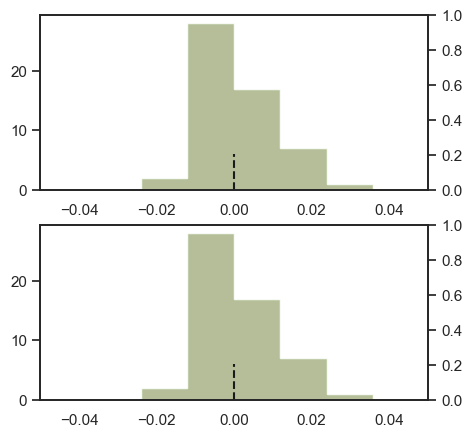

In [32]:
# bacteria / antifungals
#bac_anf = abx_matrix.loc[my_bacteria,antifungals].copy().dropna(1)
bac_anf = abx_matrix.copy().dropna()
store_anf_tmp = pd.DataFrame()
for col in bac_anf.columns:
    tmp = bac_anf.loc[:,col]
    #store_anf_tmp = pd.concat([store_anf_tmp, pd.DataFrame(tmp[tmp! = 0].get_values())])
    store_anf_tmp = pd.concat([store_anf_tmp, pd.DataFrame(tmp[tmp!=0].to_numpy())])
store_anf_tmp = store_anf_tmp.reset_index().drop(['index'],axis = 1)

# fungi / antibiotics
#fun_abx = abx_matrix.loc[my_fungi,antibacterials].copy().drop(['Aspergillus'])
fun_abx = abx_matrix.copy()
fun_abx  = fun_abx.dropna()
store_abx_tmp_fun = pd.DataFrame()
for col in fun_abx.columns:
    tmp = fun_abx.loc[:,col]
    #store_abx_tmp_fun = pd.concat([store_abx_tmp_fun, pd.DataFrame(tmp[tmp! = 0].get_values())])
    store_abx_tmp_fun = pd.concat([store_abx_tmp_fun, pd.DataFrame(tmp[tmp!=0].to_numpy())])
store_abx_tmp_fun = store_abx_tmp_fun.reset_index().drop(['index'],axis = 1)

# fungi / antifungals
#fun_anf = abx_matrix.loc[my_fungi,antifungals].copy().drop(['Aspergillus'])
fun_anf = abx_matrix.copy()
fun_anf  = fun_anf.dropna()
store_anf_tmp_fun = pd.DataFrame()
for col in fun_anf.columns:
    tmp = fun_anf.loc[:,col]
    #store_anf_tmp_fun = pd.concat([store_anf_tmp_fun, pd.DataFrame(tmp[tmp! = 0].get_values())])
    store_anf_tmp_fun = pd.concat([store_anf_tmp_fun, pd.DataFrame(tmp[tmp!=0].to_numpy())])
store_anf_tmp_fun = store_anf_tmp_fun.reset_index().drop(['index'],axis = 1)


# Plot separate histograms
fig, ax = plt.subplots(2,1, figsize = (5,5))

thresh_val = 0.05
store_abx_tmp[store_abx_tmp < -thresh_val] = -thresh_val
store_abx_tmp[store_abx_tmp > thresh_val] = thresh_val

store_anf_tmp[store_anf_tmp < -thresh_val] = -thresh_val
store_anf_tmp[store_anf_tmp > thresh_val] = thresh_val

store_abx_tmp_fun[store_abx_tmp_fun < -thresh_val] = -thresh_val
store_abx_tmp_fun[store_abx_tmp_fun > thresh_val] = thresh_val

store_anf_tmp_fun[store_anf_tmp_fun < -thresh_val] = -thresh_val
store_anf_tmp_fun[store_anf_tmp_fun > thresh_val] = thresh_val


my_bins = np.linspace(-3,3,51)*0.1
ax[0].hist(store_abx_tmp.values,
         density = False,
         bins = my_bins,
        histtype = 'stepfilled',
          color = [179/255,129/255,176/255])

ax0_2 = ax[0].twinx() 
ax[0].hist(store_anf_tmp.values,
         density = False,
         bins = my_bins,
        alpha = 0.75,
        histtype = 'stepfilled',
          color = [182/255,212/255,146/255])
ax[0].plot([0,0],[0,6],'k--')
ax[0].set_xlim([-0.05,0.05])

ax[1].hist(store_abx_tmp_fun.values,
         density = False,
         bins = my_bins,
        histtype = 'stepfilled',
          color = [179/255,129/255,176/255])
ax1_2 = ax[1].twinx() 

ax[1].hist(store_anf_tmp_fun.values,
         density = False,
         bins = my_bins,
        alpha = 0.75,
        histtype = 'stepfilled',
        color = [182/255,212/255,146/255])
ax[1].plot([0,0],[0,6],'k--')
ax[1].set_xlim([-0.05,0.05])

plt.show()

In [33]:
# Get just taxa interactions
cur_matrix = store_all_interactions.copy()
cur_matrix = cur_matrix.drop(abx_matrix.columns, axis = 1)
#cur_matrix = cur_matrix.loc[:, cur_matrix.index]
#cur_matrix[abs(cur_matrix) < 0.001] = 0

In [129]:
# Get just taxa interactions
cur_matrix = store_all_interactions.copy()
cur_matrix = cur_matrix.drop(abx_matrix.columns, axis = 1)
#cur_matrix = cur_matrix.loc[:, cur_matrix.index]
#cur_matrix[abs(cur_matrix) <0.001]=0


# Go through and count interactions
count_ints = pd.DataFrame(0, index = ['interaction'], columns = ['-/-', '-/o', '+/-', '+/o', '+/+'])

In [149]:
for ix_sp in cur_matrix.index:
    for col_sp in cur_matrix.columns:
        
        if col_sp != ix_sp:
            ci_focal = cur_matrix.loc[ix_sp, col_sp]
            ci_pair = cur_matrix.loc[col_sp, ix_sp]
            #ci_pair = cur_matrix.loc[ix_sp, col_sp]
            

            if ci_focal > 0:
                if ci_pair > 0:
                    count_ints.loc['interaction', '+/+'] = count_ints.loc['interaction', '+/+'] + 1 # pp
                if ci_pair < 0:
                    count_ints.loc['interaction', '+/-'] = count_ints.loc['interaction', '+/-'] + 1 # pm
                if ci_pair == 0:
                    count_ints.loc['interaction', '+/o'] = count_ints.loc['interaction', '+/o'] + 1 # po

            if ci_focal < 0:
                if ci_pair > 0:
                    count_ints.loc['interaction', '+/-'] = count_ints.loc['interaction', '+/-'] + 1# mp
                if ci_pair < 0:
                    count_ints.loc['interaction', '-/-'] = count_ints.loc['interaction', '-/-'] + 1# mm
                if ci_pair == 0:
                    count_ints.loc['interaction', '-/o'] = count_ints.loc['interaction', '-/o'] + 1# mo

            if ci_focal == 0:
                if ci_pair > 0:
                    count_ints.loc['interaction', '+/o'] = count_ints.loc['interaction', '+/o'] + 1# op
                if ci_pair < 0:
                    count_ints.loc['interaction', '-/o'] = count_ints.loc['interaction', '-/o'] + 1# om 
                
        
# Plot result
fig, ax = plt.subplots(1,1, figsize=(2,5))
colors = ['darkred', 'tomato', 'khaki', 'royalblue', 'darkblue']
count_ints=count_ints/count_ints.sum(1).values[0]
count_ints.plot(kind='bar',
                stacked=True,
                #colors = colors,
                color = colors,
                ax=ax)  
ax.set_ylim(0,1)
ax.legend(bbox_to_anchor=(01.6, 1.00),
          ncol=1, fancybox=True)
plt.show()

KeyError: 'Neurospora'

C:\Users\15837\AppData\Local\Temp\ipykernel_18776\2571230634.py:26: MatplotlibDeprecationWarning: The join function was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax1.get_shared_y_axes().join(ax2)


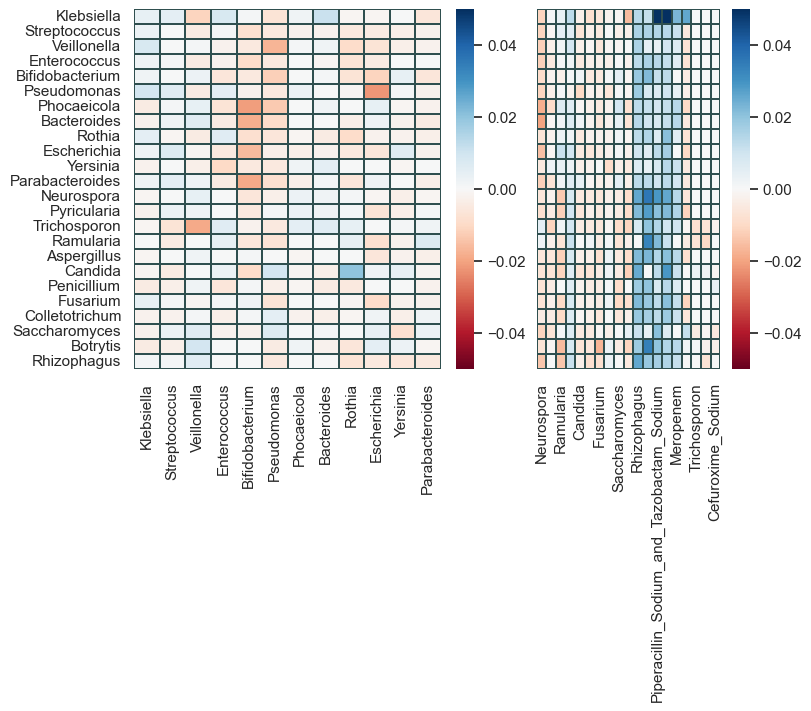

In [34]:
fig = plt.figure(constrained_layout=True, figsize=(8,7))

gs = GridSpec(1, 8, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:5])
ax2 = fig.add_subplot(gs[0, 5:8])#, sharey=ax1)

clusters =  sns.heatmap(cur_matrix.fillna(0),
               cmap='RdBu',
               center=0,
               vmin=-0.05,
               vmax=0.05,
              square=False, ax=ax1,cbar=True,yticklabels=True,linewidths=0.05,
                  linecolor = 'darkslategray',)

clusters =  sns.heatmap(abx_matrix.fillna(0),
               cmap='RdBu',
               center=0,
               vmin=-0.05,
               vmax=0.05,
              square=False,
                ax=ax2,
              cbar=True,
                yticklabels=False,
                       linewidths=0.05,
                  linecolor = 'darkslategray',)
ax1.get_shared_y_axes().join(ax2)
plt.show()

